# GPU Metrics Data Processing & Stacked TFLOPS Projection Notebook

This notebook performs end-to-end processing of GPU utilization metrics from Nessie/Iceberg tables using Spark on Enterprise Gateway (SparkCaster). It engineers deployable power features, trains a stacked model that first predicts `chip_power_hat` from redfish-based inputs, then predicts `tensor_tflops` from those same deployable features plus `chip_power_hat`, and prepares the results for downstream projection workflows.

---
#sparkcaster using "http://spark-gateway.kubeflow.svc.cluster.local:8888"

## 📋 Notebook Structure

### **Setup & Initialization** (Cells 1-5)
- Package installation, credential setup, SparkCaster session creation, and raw data load from Nessie.

### **Feature Engineering** (Cells 6-7)
- Build deployable numeric features including `redfish_power_pct_max`.
- Prepare the training frame with the columns needed for stacked modeling.

### **Stacked Model Training & Evaluation** (Cells 8-12)
- Stage 1: predict `chip_power_hat` from deployable redfish-based features.
- Stage 2: compare multiple regressors for `tensor_tflops` using deployable features + `chip_power_hat`.
- Retrain the best stacked stage-2 model on a larger sample.

### **Optional Projection / Writeback** (Cells 13+)
- Generate `chip_power_hat` and projected `tensor_tflops` for downstream use.


In [1]:
#install needed packages

import importlib
import subprocess
import sys

def is_module_available(module_name: str) -> bool:
    """Return True if the importable module exists; handles dotted names safely."""
    try:
        return importlib.util.find_spec(module_name) is not None
    except ModuleNotFoundError:
        return False

def install_if_missing(pip_name: str, import_name: str = None):
    """
    Install `pip_name` only if `import_name` (or `pip_name` if None) is not importable.
    Use this to handle cases where pip/distribution names differ from import names.
    """
    import_name = import_name or pip_name
    if not is_module_available(import_name):
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"{pip_name} already installed.")

# --- Packages for Nessie/Iceberg access ---
# simple 1:1 cases
install_if_missing("keyring", "keyring")
install_if_missing("ipython-secrets", "ipython_secrets")
install_if_missing("pyarrow", "pyarrow")
install_if_missing("fsspec", "fsspec")
install_if_missing("s3fs", "s3fs")
install_if_missing("statsmodels", "statsmodels")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("xgboost", "xgboost")

# special cases
# keyrings.cryptfile installs a plugin under the 'keyrings' package; checking the root avoids ModuleNotFoundError
install_if_missing("keyrings.cryptfile", "keyrings")

# Core viz + scaling pins for Python 3.11.11
install_if_missing("bokeh==3.6.2", "bokeh")
install_if_missing("jupyter_bokeh", "jupyter_bokeh")
install_if_missing("panel==1.5.2", "panel")
install_if_missing("holoviews==1.19.0", "holoviews")
install_if_missing("hvplot==0.10.0", "hvplot")
install_if_missing("datashader==0.16.3", "datashader")
install_if_missing("dask[dataframe]==2024.9.1", "dask")
install_if_missing("distributed==2024.9.1", "distributed")
install_if_missing("reportlab", "reportlab")


print("\n✓ All packages installed/verified")




keyring already installed.
ipython-secrets already installed.
pyarrow already installed.
fsspec already installed.
s3fs already installed.
Installing statsmodels ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 41.6 MB/s  0:00:00ta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Installing matplotlib ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 321.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 198.2 MB/s  0:00:00
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [fonttools]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
scikit-learn already installed.
Installing xgboost ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 110.2 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 179.3 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
keyrings.cryptfile already installed.
Installing bokeh==3.6.2 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 24.8 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [bokeh]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [bokeh]
Installing jupyter_bokeh ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.0 MB/s  0:00:00 eta 0:00:01
Installing panel==1.5.2 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 64.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 3/6 [bleach]

...

Installing dask[dataframe]==2024.9.1 ...
Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.1 MB/s  0:00:00eta 0:00:01
  Attempting uninstall: dask
    Found existing installation: dask 2026.6.0
    Uninstalling dask-2026.6.0:
      Successfully uninstalled dask-2026.6.0
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [dask-expr]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [dask-expr]
Installing distributed==2024.9.1 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 6.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [distributed] [distributed]
Installing reportlab ...


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.3 MB/s  0:00:00eta 0:00:01

✓ All packages installed/verified


In [2]:
#set up caios credentials
import keyring
import os
from getpass import getpass
from keyrings.cryptfile.cryptfile import CryptFileKeyring
from pathlib import Path

# Use home directory dynamically instead of hardcoded path
home_dir = str(Path.home())
os.environ["KEYRING_CRYPTFILE_PATH"] = f"{home_dir}/.local/share/python_keyring/cryptfile_pass.cfg"

kr = CryptFileKeyring()
kr.keyring_key = getpass("Set/enter master password for encrypted keyring: ")
keyring.set_keyring(kr)

# Prompt for CAIOS credentials if not already stored
caios_access_key = keyring.get_password("caios", "access_key")
caios_secret_key = keyring.get_password("caios", "secret_key")  

if not caios_access_key:
    caios_access_key = input("Enter CAIOS access key: ")
    keyring.set_password("caios", "access_key", caios_access_key)

if not caios_secret_key:
    caios_secret_key = getpass("Enter CAIOS secret key: ")
    keyring.set_password("caios", "secret_key", caios_secret_key)

print("✓ CAIOS credentials configured")

# ========================================
# StarRocks Credentials Setup
# ========================================
print("="*60)
print("StarRocks Credentials Setup")
print("="*60)

# Prompt for StarRocks credentials if not already stored
starrocks_username = keyring.get_password("starrocks", "username")
starrocks_password = keyring.get_password("starrocks", "password")

if not starrocks_username:
    starrocks_username = input("Enter StarRocks username: ")
    keyring.set_password("starrocks", "username", starrocks_username)

if not starrocks_password:
    starrocks_password = getpass("Enter StarRocks password: ")
    keyring.set_password("starrocks", "password", starrocks_password)

print("✓ StarRocks credentials configured")


✓ CAIOS credentials configured
StarRocks Credentials Setup
✓ StarRocks credentials configured


In [3]:
#credential validation
import keyring

# Retrieve CAIOS credentials from keyring
caios_access_key = keyring.get_password("caios", "access_key")
caios_secret_key = keyring.get_password("caios", "secret_key")

assert caios_access_key and caios_secret_key, "No CAIOS credentials in keyring."

print("✓ CAIOS credentials validated")
print(f"  Access key: {caios_access_key[:3]}...{caios_access_key[-3:]}")

✓ CAIOS credentials validated
  Access key: CWO...SKY


In [4]:
# CLEAN UP EXISTING SESSION
# ========================================
from spark.nessie.client import NessieSparkClient


try:
    existing_spark = SparkSession.getActiveSession()
    if existing_spark:
        print("Stopping existing Spark session...")
        existing_spark.stop()
        print("✓ Existing Spark session stopped")
    else:
        print("No existing Spark session found")
except Exception as e:
    print(f"Note: Could not check for existing session: {e}")

ness = NessieSparkClient(
    svc_url="http://kf-proxy.nessie.svc.cluster.local:19120/api/v2",
    nessie_endpoint="http://nessie-prd.cwobject.com",
    caios_access_key=caios_access_key,
    caios_secret_key=caios_secret_key,
    dbtcaster=True,
)

spark = ness.spark

spark.sparkContext.setLogLevel("ERROR")

# ========================================
# SESSION DIAGNOSTICS
# ========================================
print("=" * 60)
print("SPARK CLUSTER CONFIGURATION - NESSIE SPARK CLIENT")
print("=" * 60)
print(f"Spark Version: {spark.version}")
print(f"Spark Master: {spark.sparkContext.master}")
print(f"App Name: {spark.sparkContext.appName}")
print(f"Application ID: {spark.sparkContext.applicationId}")
print("Nessie Service URL: http://kf-proxy.nessie.svc.cluster.local:19120/api/v2")
print("Nessie Endpoint: http://nessie-prd.cwobject.com")
print("DBTCaster Mode: Enabled")
print("AWS Environment Variables: Set (AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)")

for k in [
    "spark.driver.memory",
    "spark.driver.cores",
    "spark.executor.instances",
    "spark.executor.cores",
    "spark.executor.memory",
    "spark.sql.shuffle.partitions",
    "spark.sql.adaptive.enabled",
]:
    try:
        print(f"{k}: {spark.conf.get(k)}")
    except Exception:
        print(f"{k}: <unset>")

try:
    executor_count = spark.sparkContext._jsc.sc().getExecutorMemoryStatus().size()
    print(f"Executor entries visible: {executor_count}")
except Exception as e:
    print(f"Could not inspect executor status: {e}")

print("=" * 60)



Note: Could not check for existing session: name 'SparkSession' is not defined
SPARK CLUSTER CONFIGURATION - NESSIE SPARK CLIENT
Spark Version: 4.1.2
Spark Master: k8s://https://10.16.0.1:443
App Name: sparkcaster-jbok-c57e3338-ef51-4c91-9f4b-e9a37e981ab8
Application ID: spark-b092a0a9cf244c9fb314d9fe1a74e4c2
Nessie Service URL: http://kf-proxy.nessie.svc.cluster.local:19120/api/v2
Nessie Endpoint: http://nessie-prd.cwobject.com
DBTCaster Mode: Enabled
AWS Environment Variables: Set (AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)
spark.driver.memory: 16g
spark.driver.cores: 4
spark.executor.instances: 10
spark.executor.cores: 4
spark.executor.memory: 64g
spark.sql.shuffle.partitions: 200
spark.sql.adaptive.enabled: true
Executor entries visible: 11


In [5]:
#query data
df = ness.sql("select * from nessie.staging_capacity_finance.dcgm_metrics_raw")
#df = ness.sql("select max(datestamp) from nessie.staging_capacity_finance.dcgm_metrics_raw")
df.limit(5).show(truncate=False)
df.printSchema()


+-------------------+-------+--------+-----------+------------------+-------------------+-------------+----------+-------------------+--------+--------------------+------+-----+-------+-----------+------+---------------------+------+-------------+-------------+-----------------+---------------------+-------+----------------+----------------+-----------+------------+------------------+----------------+---------------+---------------+----------------------+--------------------------+-----------------------+----------------------+----------------+-------------+-------------------------+
|datestamp          |node   |gpu_util|tensor_util|chip_power        |dram_active        |mem_copy_util|vram_usage|sm_active          |sm_clock|sm_occupancy        |region|zone |cluster|cluster_org|cw_sku|model                |serial|redfish_power|customer_name|flag_is_coreweave|model_imputed        |product|product_resolved|customer_segment|is_training|is_multinode|gpu_count_expected|peak_tflops_unit|peak_

In [6]:
# FEATURE ENGINEERING
# ========================================
# Add derived features to the raw dataset
# These features will be available for EDA, modeling, and imputation

from pyspark.sql import functions as F
from pyspark.sql.window import Window

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

print(f"\nStarting with {len(df.columns)} columns")




# Get initial count
# initial_count = df.count()
# print(f"Row count: {initial_count:,}")

# ========================================
# 1. Tensor to GPU Ratio
# ========================================
print("\n[1/5] Adding tensor_to_gpu_ratio...")
df = df.withColumn(
    "tensor_to_gpu_ratio_index",
    F.col("tensor_util") / (F.col("gpu_util") + 0.0001)
)
print("✓ tensor_to_gpu_ratio = tensor_util / (gpu_util + 0.001)")

# ========================================
# 2. Memory Intensity
# ========================================
print("\n[2/5] Adding memory_intensity...")
df = df.withColumn(
    "memory_intensity_index",
    F.col("mem_copy_util") / (F.col("gpu_util") + 0.0001)
)
print("✓ memory_intensity = mem_copy_util / (gpu_util + 0.001)")

# ========================================
# 3. Compute to Memory Ratio
# ========================================
print("\n[3/5] Adding compute_to_memory_ratio...")
df = df.withColumn(
    "compute_to_memory_ratio_index",
    F.col("tensor_tflops") / (F.col("vram_usage") + 0.0001)
)
print("✓ compute_to_memory_ratio = tensor_tflops / (vram_usage + 0.001)")

# ========================================
# 4. Power % of Max
# ========================================
print("\n[4/7] Adding power_%_max...")
df = df.withColumn(
    "power_pct_max_index",
    F.col("chip_power") / (F.col("gpu_peak_power_node_watts") + 0.0001)
)
print("✓ power_%_max = chip_power / (gpu_peak_power_node_watts + 0.001)")

# ========================================
# 5. Compute % of Max
# ========================================
print("\n[5/7] Adding compute_%_max...")
df = df.withColumn(
    "compute_pct_max_index",
    F.col("tensor_tflops") / ((F.col("peak_tflops_unit") * F.col("gpu_count_expected")) + 0.0001)
)
print("✓ compute_%_max = tensor_tflops / ((peak_tflops_unit * gpu_count_expected) + 0.001)")

# ========================================
# 6. GPU Generation
# ========================================
print("\n[6/7] Adding gen (GPU generation)...")
df = df.withColumn(
    "gen",
    F.when(
        F.col("product_resolved").isin("GB200", "GB300", "B200", "B300"),
        "current_gen"
    ).otherwise("prior_gen")
)
print("✓ gen = 'current_gen' if product_resolved in ('GB200', 'GB300', 'B200', 'B300'), else 'prior_gen'")

# Show distribution
print("\nGPU generation distribution:")
df.groupBy("gen").count().orderBy("gen").show()


# ========================================
# 7. Region Rollup
# ========================================
print("\n[7/8] Adding region_rollup...")

# Normalize region: trim whitespace, handle nulls, create region_rollup
df = df.withColumn(
    "region_rollup",
    F.when(
        F.trim(F.coalesce(F.col("region"), F.lit(""))).startswith("EU"),
        "EU"
    ).otherwise("NAM")
)

print("✓ region_rollup = 'EU' if region starts with 'EU', else 'NAM'")

# Show distribution
print("\nRegion rollup distribution:")
df.select("region", "region_rollup").distinct().orderBy("region").show(50, truncate=False)

# ========================================
# 8. Training/Inference Classification
# ========================================
print("\n[7/7] Adding training_inference classification...")

# Simple classification: if is_training == "slurm" then "active_training", else "non_training"
df = df.withColumn(
    "training_inference",
    F.when(
        F.col("is_training") == "slurm",
        "active_training"
    ).otherwise(
        "non_training"
    )
)

print("✓ training_inference classification complete:")
print("  - 'active_training': is_training = 'slurm'")
print("  - 'non_training': is_training != 'slurm'")

# ========================================
# 9. Redfish / Peak Power
# ========================================
print("\n[7/7] Adding training_inference classification...")

# Simple classification: if is_training == "slurm" then "active_training", else "non_training"
df = df.withColumn(
    "redfish_power_pct_max",
    F.col("redfish_power") / (F.col("gpu_peak_power_node_watts") + 0.0001)
)
print("✓ redfish_power_pct_max = redfish_power / gpu_peak_power_node_watts + 0.001)")

# Show distribution
# print("\nTraining/Inference distribution:")
# df.groupBy("training_inference").count().orderBy("count", ascending=False).show()

# ========================================
# Summary
# ========================================
print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)

# print(f"\nFinal column count: {len(df.columns)} columns")
print(f"Added features:")
print("  1. tensor_to_gpu_ratio")
print("  2. memory_intensity")
print("  3. compute_to_memory_ratio")
print("  4. power_%_max")
print("  5. compute_%_max")
print("  6. gen")
print("  7. region_rollup")
print("  8. training_inference")
print("  9. Redfish / Peak Power")

# Show sample with new features
print("\nSample with new features:")
df.select(
    "datestamp", "node", "region", "region_rollup", "product_resolved", "gen",
    "tensor_to_gpu_ratio_index", "memory_intensity_index", "compute_to_memory_ratio_index",
    "power_pct_max_index", "compute_pct_max_index",
    "is_training", "training_inference", "redfish_power",
    "redfish_power_pct_max"
).show(10, truncate=False)

print("\n✓ Features are now available for all downstream analysis and modeling!")

FEATURE ENGINEERING

Starting with 38 columns

[1/5] Adding tensor_to_gpu_ratio...
✓ tensor_to_gpu_ratio = tensor_util / (gpu_util + 0.001)

[2/5] Adding memory_intensity...
✓ memory_intensity = mem_copy_util / (gpu_util + 0.001)

[3/5] Adding compute_to_memory_ratio...
✓ compute_to_memory_ratio = tensor_tflops / (vram_usage + 0.001)

[4/7] Adding power_%_max...
✓ power_%_max = chip_power / (gpu_peak_power_node_watts + 0.001)

[5/7] Adding compute_%_max...
✓ compute_%_max = tensor_tflops / ((peak_tflops_unit * gpu_count_expected) + 0.001)

[6/7] Adding gen (GPU generation)...
✓ gen = 'current_gen' if product_resolved in ('GB200', 'GB300', 'B200', 'B300'), else 'prior_gen'

GPU generation distribution:
+-----------+---------+
|        gen|    count|
+-----------+---------+
|current_gen|362582701|
|  prior_gen|674257017|
+-----------+---------+


[7/8] Adding region_rollup...
✓ region_rollup = 'EU' if region starts with 'EU', else 'NAM'

Region rollup distribution:
+-------------+-------

In [7]:
# dataframe creation for stacked model
from pyspark.sql import functions as F, types as T
from pyspark.sql.functions import monotonically_increasing_id

# Training columns:
# - chip_power is kept only as the stage-1 training label
# - tensor_tflops is the final stage-2 label
# - all remaining columns are deployable features available when scoring from redfish power
num_cols = [
    "tensor_tflops",
    "chip_power",
    "redfish_power",
    "peak_power_unit",
    "gpu_peak_power_node_watts",
    "peak_tflops_unit",
    "gpu_count_expected",
    "redfish_power_pct_max"
]

sdf_num = (
    df
      .select(*num_cols)
      .na.drop()
      .select(*(F.col(c).cast(T.DoubleType()).alias(c) for c in num_cols))
)

print()
print("="*60)
print("CACHING sdf_num FOR STACKED TRAINING CELLS")
print("="*60)

sdf_num.cache()
sdf_num_count = sdf_num.count()

rows = sdf_num_count
cols = len(num_cols)
estimated_gb = (rows * cols * 8) / (1024**3)

print(f"✓ Cached sdf_num: {sdf_num_count:,} rows × {cols} columns")
print(f"  Estimated memory: ~{estimated_gb:.1f} GB (raw), ~{estimated_gb*2:.1f} GB (with overhead)")
print(f"  Available executor memory: 640 GB")
print(f"  Cache usage: ~{(estimated_gb*2/640)*100:.1f}% of executor memory")
print("="*60)



CACHING sdf_num FOR STACKED TRAINING CELLS
✓ Cached sdf_num: 705,618,324 rows × 8 columns
  Estimated memory: ~42.1 GB (raw), ~84.1 GB (with overhead)
  Available executor memory: 640 GB
  Cache usage: ~13.1% of executor memory


In [8]:
# STACKED MODEL TRAINING PIPELINE (OPTIMIZED + 5-FOLD CV HYPERPARAMS)
# ========================================
# Stage 1: predict chip_power_hat from deployable redfish-based features
# Stage 2: predict tensor_tflops from deployable features + chip_power_hat

import time
from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as MLStandardScaler
from pyspark.ml.regression import LinearRegression as MLLinearRegression, GBTRegressor, RandomForestRegressor as MLRandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F

print("="*60)
print("STACKED SPARK MLLIB TRAINING PIPELINE")
print("="*60)

SAMPLE_FRAC = 0.02
SEED = 42
NUM_FOLDS = 5

stage1_target_col = "chip_power"
target_col = "tensor_tflops"
base_feature_cols = [c for c in num_cols if c not in {target_col, stage1_target_col}]
stack_feature_col = "chip_power_hat"
feature_cols = base_feature_cols + [stack_feature_col]

print()
print(f"Stage-1 feature columns: {base_feature_cols}")
print(f"Stage-1 target column: {stage1_target_col}")
print(f"Stage-2 feature columns: {feature_cols}")
print(f"Stage-2 target column: {target_col}")
print(f"Cross-validation references: {NUM_FOLDS}-fold tuned params reused for tree models")

print()
print("[1/4] Preparing stacked training data...")
base_labeled = (
    sdf_num
    .select(*(base_feature_cols + [stage1_target_col, target_col]))
    .where(F.col(stage1_target_col).isNotNull() & F.col(target_col).isNotNull())
)

base_labeled = base_labeled.withColumn("_split_id", F.monotonically_increasing_id())
train_sdf, test_sdf = base_labeled.randomSplit([0.7, 0.3], seed=SEED)

if SAMPLE_FRAC < 1.0:
    train_sdf = train_sdf.sample(False, SAMPLE_FRAC, SEED)
    test_sdf = test_sdf.sample(False, SAMPLE_FRAC, SEED + 1)
    print(f"Split data first, then sampled {SAMPLE_FRAC*100:.0f}% from each")
else:
    print("Using full labeled dataset")

train_sdf = train_sdf.drop("_split_id")
test_sdf = test_sdf.drop("_split_id")
train_sdf.cache()
test_sdf.cache()
train_count = train_sdf.count()
test_count = test_sdf.count()

print(f"Training set: {train_count:,} rows (cached)")
print(f"Test set: {test_count:,} rows (cached)")
print(f"Num partitions: train={train_sdf.rdd.getNumPartitions()}, test={test_sdf.rdd.getNumPartitions()}")

print()
print("[2/4] Pre-assembling stage-1 deployable features...")
assembler_stage1 = VectorAssembler(
    inputCols=base_feature_cols,
    outputCol="features_base"
)

assembled_train_stage1 = (
    assembler_stage1
    .transform(train_sdf)
    .select(*(base_feature_cols + [stage1_target_col, target_col, "features_base"]))
)
assembled_test_stage1 = (
    assembler_stage1
    .transform(test_sdf)
    .select(*(base_feature_cols + [stage1_target_col, target_col, "features_base"]))
)

assembled_train_stage1.cache()
assembled_test_stage1.cache()
_ = assembled_train_stage1.count()
_ = assembled_test_stage1.count()

print("✓ Stage-1 features assembled and cached")

# Evaluators reused across both stacked stages
stage1_evaluator_r2 = RegressionEvaluator(labelCol=stage1_target_col, predictionCol=stack_feature_col, metricName="r2")
stage1_evaluator_rmse = RegressionEvaluator(labelCol=stage1_target_col, predictionCol=stack_feature_col, metricName="rmse")
stage1_evaluator_mae = RegressionEvaluator(labelCol=stage1_target_col, predictionCol=stack_feature_col, metricName="mae")

evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")

print()
print("✓ Caching status:")
print(f"  train_sdf: {train_sdf.is_cached}")
print(f"  test_sdf: {test_sdf.is_cached}")
print(f"  assembled_train_stage1: {assembled_train_stage1.is_cached}")
print(f"  assembled_test_stage1: {assembled_test_stage1.is_cached}")


STACKED SPARK MLLIB TRAINING PIPELINE

Stage-1 feature columns: ['redfish_power', 'peak_power_unit', 'gpu_peak_power_node_watts', 'peak_tflops_unit', 'gpu_count_expected', 'redfish_power_pct_max']
Stage-1 target column: chip_power
Stage-2 feature columns: ['redfish_power', 'peak_power_unit', 'gpu_peak_power_node_watts', 'peak_tflops_unit', 'gpu_count_expected', 'redfish_power_pct_max', 'chip_power_hat']
Stage-2 target column: tensor_tflops
Cross-validation references: 5-fold tuned params reused for tree models

[1/4] Preparing stacked training data...
Split data first, then sampled 2% from each


Training set: 9,875,235 rows (cached)
Test set: 4,232,677 rows (cached)
Num partitions: train=667, test=667

[2/4] Pre-assembling stage-1 deployable features...
✓ Stage-1 features assembled and cached

✓ Caching status:
  train_sdf: True
  test_sdf: True
  assembled_train_stage1: True
  assembled_test_stage1: True


In [9]:
# STAGE 1 + STAGE 2 MODEL COMPARISON
# ========================================
# Stage 1 creates chip_power_hat using deployable features only
# Stage 2 compares multiple regressors using deployable features + chip_power_hat

print()
print("[3/4] Training stage-1 chip_power proxy model...")

stage1_lr = MLLinearRegression(
    featuresCol="features_base",
    labelCol=stage1_target_col,
    predictionCol=stack_feature_col,
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    standardization=False
)

stage1_start = time.time()
stage1_model = stage1_lr.fit(assembled_train_stage1.select("features_base", stage1_target_col))
stage1_time = time.time() - stage1_start

stage1_train_pred = stage1_model.transform(assembled_train_stage1)
stage1_test_pred = stage1_model.transform(assembled_test_stage1)

stage1_train_r2 = stage1_evaluator_r2.evaluate(stage1_train_pred)
stage1_train_rmse = stage1_evaluator_rmse.evaluate(stage1_train_pred)
stage1_train_mae = stage1_evaluator_mae.evaluate(stage1_train_pred)
stage1_test_r2 = stage1_evaluator_r2.evaluate(stage1_test_pred)
stage1_test_rmse = stage1_evaluator_rmse.evaluate(stage1_test_pred)
stage1_test_mae = stage1_evaluator_mae.evaluate(stage1_test_pred)

print(f"  Training   → R²: {stage1_train_r2:.4f} | RMSE: {stage1_train_rmse:.2f} | MAE: {stage1_train_mae:.2f}")
print(f"  Test       → R²: {stage1_test_r2:.4f} | RMSE: {stage1_test_rmse:.2f} | MAE: {stage1_test_mae:.2f}")
print(f"  Training time: {stage1_time:.2f}s")

print()
print("[4/4] Materializing stacked stage-2 datasets...")
train_sdf_stack = stage1_train_pred.select(*(base_feature_cols + [target_col, stack_feature_col]))
test_sdf_stack = stage1_test_pred.select(*(base_feature_cols + [target_col, stack_feature_col]))

train_sdf_stack.cache()
test_sdf_stack.cache()
_ = train_sdf_stack.count()
_ = test_sdf_stack.count()

assembler_all = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

assembled_train = assembler_all.transform(train_sdf_stack).select("features_raw", target_col)
assembled_test = assembler_all.transform(test_sdf_stack).select("features_raw", target_col)
assembled_train.cache()
assembled_test.cache()
_ = assembled_train.count()
_ = assembled_test.count()

print("✓ Stage-2 stacked features assembled and cached")

# ========================================
# Model 1: Simple Linear Regression baseline (redfish_power only)
# ========================================
print()
print("[1/4] Training Simple Linear Regression (redfish_power only)...")

assembler_redfish = VectorAssembler(
    inputCols=["redfish_power"],
    outputCol="features_redfish"
)

simple_lr = MLLinearRegression(
    featuresCol="features_redfish",
    labelCol=target_col,
    predictionCol="prediction",
    maxIter=100,
    standardization=False
)

simple_lr_pipeline = Pipeline(stages=[assembler_redfish, simple_lr])

simple_lr_start = time.time()
simple_lr_model = simple_lr_pipeline.fit(train_sdf_stack)
simple_lr_time = time.time() - simple_lr_start

simple_lr_train_pred = simple_lr_model.transform(train_sdf_stack)
simple_lr_test_pred = simple_lr_model.transform(test_sdf_stack)

simple_lr_train_r2 = evaluator_r2.evaluate(simple_lr_train_pred)
simple_lr_train_rmse = evaluator_rmse.evaluate(simple_lr_train_pred)
simple_lr_train_mae = evaluator_mae.evaluate(simple_lr_train_pred)
simple_lr_test_r2 = evaluator_r2.evaluate(simple_lr_test_pred)
simple_lr_test_rmse = evaluator_rmse.evaluate(simple_lr_test_pred)
simple_lr_test_mae = evaluator_mae.evaluate(simple_lr_test_pred)

lr_stage = simple_lr_model.stages[-1]
print(f"  Training   → R²: {simple_lr_train_r2:.4f} | RMSE: {simple_lr_train_rmse:.2f} | MAE: {simple_lr_train_mae:.2f}")
print(f"  Test       → R²: {simple_lr_test_r2:.4f} | RMSE: {simple_lr_test_rmse:.2f} | MAE: {simple_lr_test_mae:.2f}")
print(f"  Coefficient: {lr_stage.coefficients[0]:.4f} | Intercept: {lr_stage.intercept:.2f}")
print(f"  Training time: {simple_lr_time:.2f}s")

# ========================================
# Model 2: Ridge Regression (stacked features, scaled)
# ========================================
print()
print("[2/4] Training Ridge Regression (stacked features, scaled)...")

scaler = MLStandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=False
)

ridge_lr = MLLinearRegression(
    featuresCol="features_scaled",
    labelCol=target_col,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    standardization=False
)

ridge_pipeline = Pipeline(stages=[scaler, ridge_lr])

ridge_start = time.time()
ridge_model = ridge_pipeline.fit(assembled_train)
ridge_time = time.time() - ridge_start

ridge_train_pred = ridge_model.transform(assembled_train)
ridge_test_pred = ridge_model.transform(assembled_test)

ridge_train_r2 = evaluator_r2.evaluate(ridge_train_pred)
ridge_train_rmse = evaluator_rmse.evaluate(ridge_train_pred)
ridge_train_mae = evaluator_mae.evaluate(ridge_train_pred)
ridge_test_r2 = evaluator_r2.evaluate(ridge_test_pred)
ridge_test_rmse = evaluator_rmse.evaluate(ridge_test_pred)
ridge_test_mae = evaluator_mae.evaluate(ridge_test_pred)

print(f"  Training   → R²: {ridge_train_r2:.4f} | RMSE: {ridge_train_rmse:.2f} | MAE: {ridge_train_mae:.2f}")
print(f"  Test       → R²: {ridge_test_r2:.4f} | RMSE: {ridge_test_rmse:.2f} | MAE: {ridge_test_mae:.2f}")
print(f"  Training time: {ridge_time:.2f}s")

# ========================================
# Model 3: Gradient Boosted Trees (stacked features)
# ========================================
print()
print("[3/4] Training Gradient Boosted Trees (stacked features)...")

gbt = GBTRegressor(
    featuresCol="features_raw",
    labelCol=target_col,
    predictionCol="prediction",
    maxIter=30,
    maxDepth=12,
    stepSize=0.2,
    maxBins=32,
    subsamplingRate=0.6,
    minInstancesPerNode=100,
    seed=SEED
)

gbt_start = time.time()
gbt_model = gbt.fit(assembled_train)
gbt_time = time.time() - gbt_start

gbt_train_pred = gbt_model.transform(assembled_train)
gbt_test_pred = gbt_model.transform(assembled_test)

gbt_train_r2 = evaluator_r2.evaluate(gbt_train_pred)
gbt_train_rmse = evaluator_rmse.evaluate(gbt_train_pred)
gbt_train_mae = evaluator_mae.evaluate(gbt_train_pred)
gbt_test_r2 = evaluator_r2.evaluate(gbt_test_pred)
gbt_test_rmse = evaluator_rmse.evaluate(gbt_test_pred)
gbt_test_mae = evaluator_mae.evaluate(gbt_test_pred)

feature_importance = list(zip(feature_cols, gbt_model.featureImportances.toArray()))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print(f"  Training   → R²: {gbt_train_r2:.4f} | RMSE: {gbt_train_rmse:.2f} | MAE: {gbt_train_mae:.2f}")
print(f"  Test       → R²: {gbt_test_r2:.4f} | RMSE: {gbt_test_rmse:.2f} | MAE: {gbt_test_mae:.2f}")
print(f"  Training time: {gbt_time:.2f}s")
print(f"  Hyperparameters: maxIter={gbt.getMaxIter()}, maxDepth={gbt.getMaxDepth()}, stepSize={gbt.getStepSize()}, subsample={gbt.getSubsamplingRate()}")
print()
print("  Feature Importance:")
for feat, imp in feature_importance:
    print(f"    {feat}: {imp:.4f}")

# ========================================
# Model 4: Random Forest (stacked features)
# ========================================
print()
print("[4/4] Training Random Forest (stacked features)...")

rf = MLRandomForestRegressor(
    featuresCol="features_raw",
    labelCol=target_col,
    predictionCol="prediction",
    numTrees=150,
    maxDepth=15,
    featureSubsetStrategy="sqrt",
    minInstancesPerNode=50,
    subsamplingRate=0.7,
    seed=SEED
)

rf_start = time.time()
rf_model = rf.fit(assembled_train)
rf_time = time.time() - rf_start

rf_train_pred = rf_model.transform(assembled_train)
rf_test_pred = rf_model.transform(assembled_test)

rf_train_r2 = evaluator_r2.evaluate(rf_train_pred)
rf_train_rmse = evaluator_rmse.evaluate(rf_train_pred)
rf_train_mae = evaluator_mae.evaluate(rf_train_pred)
rf_test_r2 = evaluator_r2.evaluate(rf_test_pred)
rf_test_rmse = evaluator_rmse.evaluate(rf_test_pred)
rf_test_mae = evaluator_mae.evaluate(rf_test_pred)

rf_feature_importance = list(zip(feature_cols, rf_model.featureImportances.toArray()))
rf_feature_importance.sort(key=lambda x: x[1], reverse=True)

print(f"  Training   → R²: {rf_train_r2:.4f} | RMSE: {rf_train_rmse:.2f} | MAE: {rf_train_mae:.2f}")
print(f"  Test       → R²: {rf_test_r2:.4f} | RMSE: {rf_test_rmse:.2f} | MAE: {rf_test_mae:.2f}")
print(f"  Training time: {rf_time:.2f}s")
print(f"  Hyperparameters: numTrees={rf.getNumTrees()}, maxDepth={rf.getMaxDepth()}, featureSubset={rf.getFeatureSubsetStrategy()}")
print()
print("  Feature Importance:")
for feat, imp in rf_feature_importance:
    print(f"    {feat}: {imp:.4f}")

# ========================================
# Model Comparison
# ========================================
print()
print("="*60)
print("STACKED MODEL COMPARISON")
print("="*60)

results = [
    ("Simple LR (redfish_power only)", simple_lr_train_r2, simple_lr_test_r2, simple_lr_test_rmse, simple_lr_test_mae, simple_lr_time, False),
    ("Ridge (stacked features)", ridge_train_r2, ridge_test_r2, ridge_test_rmse, ridge_test_mae, ridge_time, True),
    ("Gradient Boosting (stacked features)", gbt_train_r2, gbt_test_r2, gbt_test_rmse, gbt_test_mae, gbt_time, True),
    ("Random Forest (stacked features)", rf_train_r2, rf_test_r2, rf_test_rmse, rf_test_mae, rf_time, True)
]

print(f"{'Model':<35} {'Train R²':<10} {'Test R²':<10} {'Test RMSE':<12} {'Test MAE':<12} {'Overfit Gap':<12} {'Time (s)':<10}")
for model_name, train_r2, test_r2, test_rmse, test_mae, train_time, is_stacked in results:
    overfit_gap = train_r2 - test_r2
    print(f"{model_name:<35} {train_r2:<10.6f} {test_r2:<10.6f} {test_rmse:<12.2f} {test_mae:<12.2f} {overfit_gap:<12.6f} {train_time:<10.2f}")

stacked_result_indices = [i for i, r in enumerate(results) if r[6]]
best_model_idx = max(stacked_result_indices, key=lambda i: results[i][2])
best_model_name, _, best_test_r2, _, _, _, _ = results[best_model_idx]

print()
print(f"✓ Best Stage-2 Stacked Model (based on Test R²): {best_model_name}")
print(f"  Test R²: {best_test_r2:.4f}")

total_time = stage1_time + sum(r[5] for r in results)
print()
print(f"⚡ Total training time incl. stage 1: {total_time:.2f}s")

trained_models = {
    "stage1": {
        "model": stage1_model,
        "hyperparameters": {
            "regParam": stage1_lr.getRegParam(),
            "elasticNetParam": stage1_lr.getElasticNetParam()
        },
        "metrics": {
            "train_r2": stage1_train_r2,
            "test_r2": stage1_test_r2,
            "test_rmse": stage1_test_rmse,
            "test_mae": stage1_test_mae
        }
    },
    "Simple LR (redfish_power only)": {
        "model": simple_lr_model,
        "hyperparameters": {},
        "metrics": {"train_r2": simple_lr_train_r2, "test_r2": simple_lr_test_r2, "test_rmse": simple_lr_test_rmse, "test_mae": simple_lr_test_mae}
    },
    "Ridge (stacked features)": {
        "model": ridge_model,
        "hyperparameters": {"regParam": ridge_lr.getRegParam(), "elasticNetParam": ridge_lr.getElasticNetParam()},
        "metrics": {"train_r2": ridge_train_r2, "test_r2": ridge_test_r2, "test_rmse": ridge_test_rmse, "test_mae": ridge_test_mae}
    },
    "Gradient Boosting (stacked features)": {
        "model": gbt_model,
        "hyperparameters": {
            "maxIter": gbt.getMaxIter(),
            "maxDepth": gbt.getMaxDepth(),
            "stepSize": gbt.getStepSize(),
            "subsamplingRate": gbt.getSubsamplingRate(),
            "minInstancesPerNode": gbt.getMinInstancesPerNode(),
            "maxBins": gbt.getMaxBins()
        },
        "metrics": {"train_r2": gbt_train_r2, "test_r2": gbt_test_r2, "test_rmse": gbt_test_rmse, "test_mae": gbt_test_mae}
    },
    "Random Forest (stacked features)": {
        "model": rf_model,
        "hyperparameters": {
            "numTrees": rf.getNumTrees(),
            "maxDepth": rf.getMaxDepth(),
            "featureSubsetStrategy": rf.getFeatureSubsetStrategy(),
            "minInstancesPerNode": rf.getMinInstancesPerNode(),
            "subsamplingRate": rf.getSubsamplingRate()
        },
        "metrics": {"train_r2": rf_train_r2, "test_r2": rf_test_r2, "test_rmse": rf_test_rmse, "test_mae": rf_test_mae}
    }
}

print()
print("✓ Stage-1 model and stage-2 models saved for retraining")
print("NOTE: stage-2 training uses in-sample chip_power_hat on the training split.")
print("For a stricter offline estimate later, replace this with out-of-fold stage-1 predictions.")



[3/4] Training stage-1 chip_power proxy model...
  Training   → R²: 0.6121 | RMSE: 1227.58 | MAE: 800.71
  Test       → R²: 0.6350 | RMSE: 1189.75 | MAE: 800.25
  Training time: 2.34s

[4/4] Materializing stacked stage-2 datasets...
✓ Stage-2 stacked features assembled and cached

[1/4] Training Simple Linear Regression (redfish_power only)...
  Training   → R²: 0.3354 | RMSE: 3321.64 | MAE: 2034.43
  Test       → R²: 0.3460 | RMSE: 3295.77 | MAE: 2034.99
  Coefficient: 0.8988 | Intercept: -1166.17
  Training time: 1.52s

[2/4] Training Ridge Regression (stacked features, scaled)...
  Training   → R²: 0.4111 | RMSE: 3126.65 | MAE: 1939.31
  Test       → R²: 0.4231 | RMSE: 3095.35 | MAE: 1940.43
  Training time: 2.68s

[3/4] Training Gradient Boosted Trees (stacked features)...
  Training   → R²: 0.5395 | RMSE: 2765.06 | MAE: 1535.83
  Test       → R²: 0.5384 | RMSE: 2768.90 | MAE: 1537.82
  Training time: 170.16s
  Hyperparameters: maxIter=30, maxDepth=12, stepSize=0.2, subsample=0.6


In [10]:
# # DIAGNOSTIC PLOTS: QQ Plot & Predicted vs Actual (ALL MODELS)
# # ========================================
# # Visualizes model performance and residual distribution for ALL trained models

# # Install visualization packages (SparkCaster kernel workaround)
# import subprocess
# import sys
# import importlib
# import site

# def install_and_import(package_name, import_name=None):
#     """Install package and reload site-packages to make it importable"""
#     if import_name is None:
#         import_name = package_name
    
#     try:
#         return __import__(import_name)
#     except ImportError:
#         print(f"Installing {package_name}...")
#         subprocess.check_call([
#             sys.executable, '-m', 'pip', 'install', 
#             '--user', '--upgrade', package_name
#         ])
#         # Reload site packages to pick up newly installed packages
#         importlib.reload(site)
#         # Force reimport of sys.path
#         import site as site_module
#         site_module.main()
#         return __import__(import_name)

# # Install required packages
# install_and_import('matplotlib')
# install_and_import('scipy')

# import matplotlib.pyplot as plt
# import numpy as np
# from scipy import stats

# print("="*60)
# print("GENERATING DIAGNOSTIC PLOTS FOR ALL MODELS")
# print("="*60)

# # ========================================
# # Sample data for visualization (use test set)
# # ========================================
# # Don't plot all rows - sample for performance
# PLOT_SAMPLE_SIZE = 10000  # Plot 10k points max

# # Define all models to plot
# models_to_plot = [
#     ('Simple LR (chip_power)', simple_lr_test_pred, simple_lr_test_r2),
#     ('Ridge (all features)', ridge_test_pred, ridge_test_r2),
#     ('Gradient Boosting', gbt_test_pred, gbt_test_r2),
#     ('Random Forest', rf_test_pred, rf_test_r2)
# ]

# # ========================================
# # Generate plots for each model
# # ========================================
# for model_name, test_pred_sdf, test_r2 in models_to_plot:
#     print(f"\n{'='*60}")
#     print(f"Model: {model_name} (Test R²: {test_r2:.4f})")
#     print('='*60)
    
#     # Sample and convert to pandas for plotting
#     test_sample = test_pred_sdf.select(target_col, "prediction") \
#         .sample(False, min(1.0, PLOT_SAMPLE_SIZE / test_count)) \
#         .toPandas()
    
#     actuals = test_sample[target_col].values
#     predictions = test_sample['prediction'].values
#     residuals = actuals - predictions
    
#     print(f"Plotting {len(actuals):,} sampled points from test set")
    
#     # Create filename-safe model name
#     filename_safe = model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    
#     # ========================================
#     # Figure 1: QQ Plot (Residuals Normality Check)
#     # ========================================
#     fig1, ax1 = plt.subplots(figsize=(10, 6))
    
#     # Create QQ plot
#     stats.probplot(residuals, dist="norm", plot=ax1)
    
#     ax1.set_title(f'QQ Plot: Residuals Normality Check\n{model_name} (Test Set)', 
#                   fontsize=14, fontweight='bold')
#     ax1.set_xlabel('Theoretical Quantiles', fontsize=12)
#     ax1.set_ylabel('Sample Quantiles (Residuals)', fontsize=12)
#     ax1.grid(True, alpha=0.3)
    
#     # Style the points
#     ax1.get_lines()[0].set_markerfacecolor('blue')
#     ax1.get_lines()[0].set_markeredgecolor('blue')
#     ax1.get_lines()[0].set_markersize(4)
#     ax1.get_lines()[0].set_alpha(0.6)
    
#     # Calculate normality statistics
#     _, p_value = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
#     skewness = stats.skew(residuals)
#     kurtosis = stats.kurtosis(residuals)
    
#     # Add statistics text box
#     stats_text = f'Shapiro-Wilk p-value: {p_value:.4f}\n'
#     stats_text += f'Skewness: {skewness:.3f}\n'
#     stats_text += f'Kurtosis: {kurtosis:.3f}\n'
#     stats_text += f'\nResiduals ~ Normal' if p_value > 0.05 else f'\nResiduals not normal'
    
#     ax1.text(0.05, 0.95, stats_text,
#              transform=ax1.transAxes,
#              fontsize=10,
#              verticalalignment='top',
#              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
#     plt.tight_layout()
#     filename = f'qq_plot_{filename_safe}.png'
#     plt.savefig(filename, dpi=150, bbox_inches='tight')
#     print(f"  ✓ Saved: {filename}")
#     plt.show()
    
#     # ========================================
#     # Figure 2: Predicted vs Actual Scatter Plot
#     # ========================================
#     fig2, ax2 = plt.subplots(figsize=(10, 8))
    
#     # Scatter plot with alpha for overlap visualization
#     ax2.scatter(actuals, predictions, alpha=0.5, s=20, c='blue', edgecolors='none')
    
#     # Perfect prediction line (45-degree)
#     min_val = min(actuals.min(), predictions.min())
#     max_val = max(actuals.max(), predictions.max())
#     ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
#     # Add best fit line
#     z = np.polyfit(actuals, predictions, 1)
#     p = np.poly1d(z)
#     ax2.plot(actuals, p(actuals), "g-", linewidth=2, label=f'Best Fit: y={z[0]:.3f}x+{z[1]:.1f}')
    
#     ax2.set_xlabel(f'Actual {target_col}', fontsize=12)
#     ax2.set_ylabel(f'Predicted {target_col}', fontsize=12)
#     ax2.set_title(f'Predicted vs Actual: {model_name}\nTest Set (n={len(actuals):,})', 
#                   fontsize=14, fontweight='bold')
#     ax2.legend(loc='upper left', fontsize=10)
#     ax2.grid(True, alpha=0.3)
    
#     # Add metrics text box
#     metrics_text = f'Test R²: {test_r2:.4f}\n'
#     metrics_text += f'RMSE: {np.sqrt(np.mean(residuals**2)):.2f}\n'
#     metrics_text += f'MAE: {np.mean(np.abs(residuals)):.2f}\n'
#     metrics_text += f'Mean Residual: {np.mean(residuals):.2f}'
    
#     ax2.text(0.05, 0.95, metrics_text,
#              transform=ax2.transAxes,
#              fontsize=10,
#              verticalalignment='top',
#              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
#     plt.tight_layout()
#     filename = f'predicted_vs_actual_{filename_safe}.png'
#     plt.savefig(filename, dpi=150, bbox_inches='tight')
#     print(f"  ✓ Saved: {filename}")
#     plt.show()
    
#     # ========================================
#     # Figure 3: Residuals Histogram
#     # ========================================
#     fig3, ax3 = plt.subplots(figsize=(10, 6))
    
#     ax3.hist(residuals, bins=50, alpha=0.7, color='blue', edgecolor='black')
#     ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
#     ax3.axvline(np.mean(residuals), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(residuals):.2f}')
    
#     ax3.set_xlabel('Residuals (Actual - Predicted)', fontsize=12)
#     ax3.set_ylabel('Frequency', fontsize=12)
#     ax3.set_title(f'Residuals Distribution: {model_name}\nTest Set', 
#                   fontsize=14, fontweight='bold')
#     ax3.legend(fontsize=10)
#     ax3.grid(True, alpha=0.3, axis='y')
    
#     plt.tight_layout()
#     filename = f'residuals_histogram_{filename_safe}.png'
#     plt.savefig(filename, dpi=150, bbox_inches='tight')
#     print(f"  ✓ Saved: {filename}")
#     plt.show()
    
#     # Print diagnostic summary for this model
#     print(f"\n  Residuals Mean: {np.mean(residuals):.2f} (should be ~0)")
#     print(f"  Residuals Std: {np.std(residuals):.2f}")
#     print(f"  Residuals Range: [{residuals.min():.2f}, {residuals.max():.2f}]")
#     print(f"  Normality (Shapiro-Wilk p-value): {p_value:.4f}")
#     if p_value > 0.05:
#         print("    → Residuals appear normally distributed ✓")
#     else:
#         print("    → Residuals may not be normally distributed")

# print("\n" + "="*60)

# # ========================================
# # Generate Combined HTML Report
# # ========================================
# print("\n" + "="*60)
# print("GENERATING HTML REPORT")
# print("="*60)

# html_content = '''<!DOCTYPE html>
# <html>
# <head>
#     <title>Model Diagnostic Report - GPU Metrics Prediction</title>
#     <style>
#         body {
#             font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
#             margin: 40px;
#             background-color: #f5f5f5;
#         }
#         h1 {
#             color: #2c3e50;
#             border-bottom: 3px solid #3498db;
#             padding-bottom: 10px;
#         }
#         h2 {
#             color: #34495e;
#             margin-top: 40px;
#             background-color: #ecf0f1;
#             padding: 10px;
#             border-left: 5px solid #3498db;
#         }
#         .model-section {
#             background-color: white;
#             padding: 20px;
#             margin: 20px 0;
#             border-radius: 8px;
#             box-shadow: 0 2px 4px rgba(0,0,0,0.1);
#         }
#         .metrics {
#             display: grid;
#             grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
#             gap: 15px;
#             margin: 20px 0;
#         }
#         .metric-card {
#             background-color: #ecf0f1;
#             padding: 15px;
#             border-radius: 5px;
#             text-align: center;
#         }
#         .metric-label {
#             font-size: 12px;
#             color: #7f8c8d;
#             text-transform: uppercase;
#         }
#         .metric-value {
#             font-size: 24px;
#             font-weight: bold;
#             color: #2c3e50;
#             margin-top: 5px;
#         }
#         .plot-grid {
#             display: grid;
#             grid-template-columns: repeat(auto-fit, minmax(400px, 1fr));
#             gap: 20px;
#             margin: 20px 0;
#         }
#         .plot-container {
#             text-align: center;
#         }
#         .plot-container img {
#             max-width: 100%;
#             border: 1px solid #ddd;
#             border-radius: 5px;
#             box-shadow: 0 2px 4px rgba(0,0,0,0.1);
#         }
#         .plot-title {
#             font-weight: bold;
#             margin: 10px 0;
#             color: #34495e;
#         }
#         .best-model {
#             background-color: #d5f4e6;
#             border-left: 5px solid #27ae60;
#         }
#         .summary-table {
#             width: 100%;
#             border-collapse: collapse;
#             margin: 20px 0;
#             background-color: white;
#         }
#         .summary-table th {
#             background-color: #3498db;
#             color: white;
#             padding: 12px;
#             text-align: left;
#         }
#         .summary-table td {
#             padding: 10px;
#             border-bottom: 1px solid #ddd;
#         }
#         .summary-table tr:hover {
#             background-color: #f5f5f5;
#         }
#         .best-row {
#             background-color: #d5f4e6 !important;
#             font-weight: bold;
#         }
#     </style>
# </head>
# <body>
#     <h1>🔍 Model Diagnostic Report: GPU Metrics Prediction</h1>
#     <p><strong>Target Variable:</strong> redfish_power</p>
#     <p><strong>Features:</strong> tensor_util, gpu_util, tensor_tflops, chip_power</p>
#     <p><strong>Generated:</strong> ''' + time.strftime('%Y-%m-%d %H:%M:%S') + '''</p>
    
#     <h2>📊 Model Performance Summary</h2>
#     <table class="summary-table">
#         <thead>
#             <tr>
#                 <th>Model</th>
#                 <th>Test R²</th>
#                 <th>Test R²</th>
#                 <th>Test RMSE</th>
#                 <th>Test MAE</th>
#             </tr>
#         </thead>
#         <tbody>
# '''

# # Add each model's summary (using test R² since we no longer do CV)
# models_summary = [
#     ('Simple LR (chip_power)', simple_lr_test_r2, simple_lr_test_r2, simple_lr_test_rmse, simple_lr_test_mae),
#     ('Ridge (all features)', ridge_test_r2, ridge_test_r2, ridge_test_rmse, ridge_test_mae),
#     ('Gradient Boosting', gbt_test_r2, gbt_test_r2, gbt_test_rmse, gbt_test_mae),
#     ('Random Forest', rf_test_r2, rf_test_r2, rf_test_rmse, rf_test_mae)
# ]

# best_test_r2_value = max([m[1] for m in models_summary])

# for model_name, test_r2_display, test_r2, test_rmse, test_mae in models_summary:
#     row_class = 'best-row' if cv_r2 == best_cv_r2_value else ''
#     html_content += f'''            <tr class="{row_class}">
#                 <td>{model_name}</td>
#                 <td>{cv_r2:.4f}</td>
#                 <td>{test_r2:.4f}</td>
#                 <td>{test_rmse:.2f}</td>
#                 <td>{test_mae:.2f}</td>
#             </tr>
# '''

# html_content += '''        </tbody>
#     </table>
# '''

# # Add detailed sections for each model
# for model_name, test_pred_sdf, test_r2 in models_to_plot:
#     # Determine if this is the best model
#     is_best = test_r2 == max([m[2] for m in models_to_plot])
#     section_class = 'model-section best-model' if is_best else 'model-section'
#     best_badge = ' 🏆 BEST MODEL' if is_best else ''
    
#     # Create filename-safe model name
#     filename_safe = model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    
#     # Get model-specific metrics
#     if model_name == 'Simple LR (chip_power)':
#         cv_r2, test_rmse, test_mae = simple_lr_cv_r2, simple_lr_test_rmse, simple_lr_test_mae
#     elif model_name == 'Ridge (all features)':
#         cv_r2, test_rmse, test_mae = ridge_cv_r2, ridge_test_rmse, ridge_test_mae
#     elif model_name == 'Gradient Boosting':
#         cv_r2, test_rmse, test_mae = gbt_cv_r2, gbt_test_rmse, gbt_test_mae
#     else:  # Random Forest
#         cv_r2, test_rmse, test_mae = rf_cv_r2, rf_test_rmse, rf_test_mae
    
#     html_content += f'''
#     <div class="{section_class}">
#         <h2>{model_name}{best_badge}</h2>
        
#         <div class="metrics">
#             <div class="metric-card">
#                 <div class="metric-label">CV R² (5-fold)</div>
#                 <div class="metric-value">{cv_r2:.4f}</div>
#             </div>
#             <div class="metric-card">
#                 <div class="metric-label">Test R²</div>
#                 <div class="metric-value">{test_r2:.4f}</div>
#             </div>
#             <div class="metric-card">
#                 <div class="metric-label">Test RMSE</div>
#                 <div class="metric-value">{test_rmse:.2f}</div>
#             </div>
#             <div class="metric-card">
#                 <div class="metric-label">Test MAE</div>
#                 <div class="metric-value">{test_mae:.2f}</div>
#             </div>
#         </div>
        
#         <div class="plot-grid">
#             <div class="plot-container">
#                 <div class="plot-title">QQ Plot (Residuals Normality)</div>
#                 <img src="qq_plot_{filename_safe}.png" alt="QQ Plot">
#             </div>
#             <div class="plot-container">
#                 <div class="plot-title">Predicted vs Actual</div>
#                 <img src="predicted_vs_actual_{filename_safe}.png" alt="Predicted vs Actual">
#             </div>
#             <div class="plot-container">
#                 <div class="plot-title">Residuals Distribution</div>
#                 <img src="residuals_histogram_{filename_safe}.png" alt="Residuals Histogram">
#             </div>
#         </div>
#     </div>
# '''

# html_content += '''
#     <div class="model-section">
#         <h2>📝 Notes</h2>
#         <ul>
#             <li><strong>CV R²:</strong> Average R² across 5-fold cross-validation (training performance estimate)</li>
#             <li><strong>Test R²:</strong> R² on held-out test set (true generalization performance)</li>
#             <li><strong>QQ Plot:</strong> Points should follow the red line if residuals are normally distributed</li>
#             <li><strong>Predicted vs Actual:</strong> Points should cluster around the red diagonal line</li>
#             <li><strong>Residuals:</strong> Should be centered around zero with symmetric distribution</li>
#         </ul>
#     </div>
# </body>
# </html>
# '''

# # Write HTML file
# html_filename = 'model_diagnostics_report.html'
# with open(html_filename, 'w') as f:
#     f.write(html_content)

# print(f"\n✓ Saved HTML report: {html_filename}")
# print(f"  Open this file in a web browser to view all diagnostics")

# print("ALL DIAGNOSTIC PLOTS COMPLETE")
# print("="*60)
# print(f"\n✓ Generated 12 plots total (3 plots × 4 models)")
# print(f"✓ Files saved in current directory")
# print("\nFiles created:")
# print("  - qq_plot_simple_lr_chip_power.png")
# print("  - predicted_vs_actual_simple_lr_chip_power.png")
# print("  - residuals_histogram_simple_lr_chip_power.png")
# print("  - qq_plot_ridge_all_features.png")
# print("  - predicted_vs_actual_ridge_all_features.png")
# print("  - residuals_histogram_ridge_all_features.png")
# print("  - qq_plot_gradient_boosting.png")
# print("  - predicted_vs_actual_gradient_boosting.png")
# print("  - residuals_histogram_gradient_boosting.png")
# print("  - qq_plot_random_forest.png")
# print("  - predicted_vs_actual_random_forest.png")
# print("  - residuals_histogram_random_forest.png")
# print("="*60)



In [11]:
# # Unpersist to free memory
assembled_train.unpersist()
assembled_test.unpersist()
#assembled_train_scaled.unpersist()
#assembled_test_scaled.unpersist()
train_sdf.unpersist()
test_sdf.unpersist()

#spark.catalog.clearCache()
print("\n✓ Training complete and memory released")


✓ Training complete and memory released


In [20]:
# FINAL TRAINING: Retrain Best Stacked Model on 10% Sample
# ========================================
# Refit stage 1 (chip_power_hat) and the best stage-2 stacked model on a larger sample.

import time
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as MLStandardScaler
from pyspark.ml.regression import LinearRegression as MLLinearRegression, GBTRegressor, RandomForestRegressor as MLRandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F

print("="*60)
print("FINAL STACKED TRAINING ON 10% SAMPLE")
print("="*60)

FINAL_SAMPLE_FRAC = 0.10
SEED = 42

best_model_info = trained_models[best_model_name]
best_hyperparams = best_model_info['hyperparameters']
stage1_hyperparams = trained_models['stage1']['hyperparameters']

print()
print(f"Best Stage-2 Model from Cell 9: {best_model_name}")
print(f"Stage-2 Test R²: {best_model_info['metrics']['test_r2']:.4f}")
print(f"Stage-2 Hyperparameters: {best_hyperparams}")
print(f"Stage-1 Hyperparameters: {stage1_hyperparams}")
print(f"Increasing sample from {SAMPLE_FRAC*100:.0f}% to {FINAL_SAMPLE_FRAC*100:.0f}%...")

print()
print("[1/5] Preparing 10% stacked sample...")
base_labeled_final = (
    sdf_num
    .select(*(base_feature_cols + [stage1_target_col, target_col]))
    .where(F.col(stage1_target_col).isNotNull() & F.col(target_col).isNotNull())
)

base_labeled_final = base_labeled_final.withColumn("_split_id", F.monotonically_increasing_id())
train_sdf_final, test_sdf_final = base_labeled_final.randomSplit([0.7, 0.3], seed=SEED)
train_sdf_final = train_sdf_final.sample(False, FINAL_SAMPLE_FRAC, SEED)
test_sdf_final = test_sdf_final.sample(False, FINAL_SAMPLE_FRAC, SEED + 1)
train_sdf_final = train_sdf_final.drop("_split_id")
test_sdf_final = test_sdf_final.drop("_split_id")

train_sdf_final.cache()
test_sdf_final.cache()
train_count_final = train_sdf_final.count()
test_count_final = test_sdf_final.count()

print(f"Training set: {train_count_final:,} rows (cached)")
print(f"Test set: {test_count_final:,} rows (cached)")

print()
print("[2/5] Fitting stage-1 chip_power proxy on 10% sample...")
assembler_stage1_final = VectorAssembler(
    inputCols=base_feature_cols,
    outputCol="features_base"
)

assembled_train_stage1_final = (
    assembler_stage1_final
    .transform(train_sdf_final)
    .select(*(base_feature_cols + [stage1_target_col, target_col, "features_base"]))
)
assembled_test_stage1_final = (
    assembler_stage1_final
    .transform(test_sdf_final)
    .select(*(base_feature_cols + [stage1_target_col, target_col, "features_base"]))
)

assembled_train_stage1_final.cache()
assembled_test_stage1_final.cache()
_ = assembled_train_stage1_final.count()
_ = assembled_test_stage1_final.count()

stage1_final_lr = MLLinearRegression(
    featuresCol="features_base",
    labelCol=stage1_target_col,
    predictionCol=stack_feature_col,
    maxIter=100,
    regParam=stage1_hyperparams['regParam'],
    elasticNetParam=stage1_hyperparams['elasticNetParam'],
    standardization=False
)

stage1_final_start = time.time()
final_stage1_model = stage1_final_lr.fit(assembled_train_stage1_final.select("features_base", stage1_target_col))
stage1_final_time = time.time() - stage1_final_start

stage1_final_train_pred = final_stage1_model.transform(assembled_train_stage1_final)
stage1_final_test_pred = final_stage1_model.transform(assembled_test_stage1_final)

stage1_final_train_r2 = stage1_evaluator_r2.evaluate(stage1_final_train_pred)
stage1_final_test_r2 = stage1_evaluator_r2.evaluate(stage1_final_test_pred)
stage1_final_test_rmse = stage1_evaluator_rmse.evaluate(stage1_final_test_pred)
stage1_final_test_mae = stage1_evaluator_mae.evaluate(stage1_final_test_pred)

print(f"  Stage-1 Train/Test R²: {stage1_final_train_r2:.4f} / {stage1_final_test_r2:.4f}")
print(f"  Stage-1 Test RMSE/MAE: {stage1_final_test_rmse:.2f} / {stage1_final_test_mae:.2f}")
print(f"  Stage-1 training time: {stage1_final_time:.2f}s")

print()
print("[3/5] Building stage-2 stacked features...")
train_sdf_stack_final = stage1_final_train_pred.select(*(base_feature_cols + [target_col, stack_feature_col]))
test_sdf_stack_final = stage1_final_test_pred.select(*(base_feature_cols + [target_col, stack_feature_col]))

assembler_final = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

assembled_train_final = assembler_final.transform(train_sdf_stack_final).select("features_raw", target_col)
assembled_test_final = assembler_final.transform(test_sdf_stack_final).select("features_raw", target_col)
assembled_train_final.cache()
assembled_test_final.cache()
_ = assembled_train_final.count()
_ = assembled_test_final.count()

print("✓ Stage-2 features assembled and cached")

print()
print(f"[4/5] Retraining {best_model_name} on 10% sample...")

evaluator_r2_final = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
evaluator_rmse_final = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
evaluator_mae_final = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")

if best_model_name == 'Ridge (stacked features)':
    scaler_final = MLStandardScaler(
        inputCol="features_raw",
        outputCol="features_scaled",
        withStd=True,
        withMean=False
    )

    ridge_lr_final = MLLinearRegression(
        featuresCol="features_scaled",
        labelCol=target_col,
        predictionCol="prediction",
        maxIter=100,
        regParam=best_hyperparams['regParam'],
        elasticNetParam=best_hyperparams['elasticNetParam'],
        standardization=False
    )

    pipeline_final = Pipeline(stages=[scaler_final, ridge_lr_final])
    train_data_final = assembled_train_final
    test_data_final = assembled_test_final
    final_start = time.time()
    final_model = pipeline_final.fit(train_data_final)
    final_time = time.time() - final_start

elif best_model_name == 'Gradient Boosting (stacked features)':
    gbt_final = GBTRegressor(
        featuresCol="features_raw",
        labelCol=target_col,
        predictionCol="prediction",
        maxIter=best_hyperparams['maxIter'],
        maxDepth=best_hyperparams['maxDepth'],
        stepSize=best_hyperparams['stepSize'],
        subsamplingRate=best_hyperparams['subsamplingRate'],
        minInstancesPerNode=best_hyperparams['minInstancesPerNode'],
        maxBins=best_hyperparams['maxBins'],
        seed=SEED
    )
    final_start = time.time()
    final_model = gbt_final.fit(assembled_train_final)
    final_time = time.time() - final_start

else:
    rf_final = MLRandomForestRegressor(
        featuresCol="features_raw",
        labelCol=target_col,
        predictionCol="prediction",
        numTrees=best_hyperparams['numTrees'],
        maxDepth=best_hyperparams['maxDepth'],
        featureSubsetStrategy=best_hyperparams['featureSubsetStrategy'],
        minInstancesPerNode=best_hyperparams['minInstancesPerNode'],
        subsamplingRate=best_hyperparams['subsamplingRate'],
        seed=SEED
    )
    final_start = time.time()
    final_model = rf_final.fit(assembled_train_final)
    final_time = time.time() - final_start

final_train_pred = final_model.transform(assembled_train_final)
final_test_pred = final_model.transform(assembled_test_final)

final_train_r2 = evaluator_r2_final.evaluate(final_train_pred)
final_train_rmse = evaluator_rmse_final.evaluate(final_train_pred)
final_train_mae = evaluator_mae_final.evaluate(final_train_pred)
final_test_r2 = evaluator_r2_final.evaluate(final_test_pred)
final_test_rmse = evaluator_rmse_final.evaluate(final_test_pred)
final_test_mae = evaluator_mae_final.evaluate(final_test_pred)

print()
print(f"  Training   → R²: {final_train_r2:.4f} | RMSE: {final_train_rmse:.2f} | MAE: {final_train_mae:.2f}")
print(f"  Test       → R²: {final_test_r2:.4f} | RMSE: {final_test_rmse:.2f} | MAE: {final_test_mae:.2f}")
print(f"  Stage-2 training time: {final_time:.2f}s")

if best_model_name in ['Gradient Boosting (stacked features)', 'Random Forest (stacked features)']:
    feature_importance_final = list(zip(feature_cols, final_model.featureImportances.toArray()))
    feature_importance_final.sort(key=lambda x: x[1], reverse=True)
    print()
    print("  Feature Importance:")
    for feat, imp in feature_importance_final:
        print(f"    {feat}: {imp:.4f}")

print()
print("[5/5] Comparison: {:.0f}% vs {:.0f}% Sample".format(SAMPLE_FRAC*100, FINAL_SAMPLE_FRAC*100))
print("="*60)

import pandas as pd
comparison_final = pd.DataFrame({
    'Metric': ['Sample Size', 'Training Rows', 'Test Rows', 'Stage-1 Test R²', 'Stage-2 Test R²', 'Stage-2 Test RMSE', 'Stage-2 Test MAE', 'Stage-2 Training Time (s)'],
    f'{SAMPLE_FRAC*100:.0f}% Sample': [
        f'{SAMPLE_FRAC*100:.0f}%',
        f'{train_count:,}',
        f'{test_count:,}',
        f"{trained_models['stage1']['metrics']['test_r2']:.4f}",
        f"{best_model_info['metrics']['test_r2']:.4f}",
        f"{best_model_info['metrics']['test_rmse']:.2f}",
        f"{best_model_info['metrics']['test_mae']:.2f}",
        'N/A'
    ],
    f'{FINAL_SAMPLE_FRAC*100:.0f}% Sample': [
        f'{FINAL_SAMPLE_FRAC*100:.0f}%',
        f'{train_count_final:,}',
        f'{test_count_final:,}',
        f'{stage1_final_test_r2:.4f}',
        f'{final_test_r2:.4f}',
        f'{final_test_rmse:.2f}',
        f'{final_test_mae:.2f}',
        f'{final_time:.2f}'
    ]
})
print(comparison_final.to_string(index=False))

improvement = final_test_r2 - best_model_info['metrics']['test_r2']
print()
print(f"✓ Stage-2 Test R² improvement: {improvement:+.4f} ({improvement/best_model_info['metrics']['test_r2']*100:+.1f}%)")

print()
print("="*60)
print("FINAL STACKED MODEL SUMMARY")
print("="*60)
print(f"Stage-1 model: LinearRegression -> {stack_feature_col}")
print(f"Stage-2 model: {best_model_name}")
print(f"Training Data: {train_count_final:,} rows ({FINAL_SAMPLE_FRAC*100:.0f}% of labeled data)")
print(f"Stage-2 Hyperparameters: {best_hyperparams}")
print(f"Stage-1 Test R²: {stage1_final_test_r2:.4f}")
print(f"Stage-2 Test R²: {final_test_r2:.4f}")
print(f"Stage-2 Test RMSE: {final_test_rmse:.2f}")
print(f"Stage-2 Test MAE: {final_test_mae:.2f}")
print(f"Overfit Gap: {final_train_r2 - final_test_r2:.4f}")
print("="*60)

final_base_feature_cols = base_feature_cols
final_stage2_feature_cols = feature_cols

assembled_train_stage1_final.unpersist()
assembled_test_stage1_final.unpersist()
assembled_train_final.unpersist()
assembled_test_final.unpersist()
train_sdf_final.unpersist()
test_sdf_final.unpersist()

print()
print("✓ Final stacked training complete and memory released")


FINAL STACKED TRAINING ON 10% SAMPLE

Best Stage-2 Model from Cell 9: Gradient Boosting (stacked features)
Stage-2 Test R²: 0.5384
Stage-2 Hyperparameters: {'maxIter': 30, 'maxDepth': 12, 'stepSize': 0.2, 'subsamplingRate': 0.6, 'minInstancesPerNode': 100, 'maxBins': 32}
Stage-1 Hyperparameters: {'regParam': 0.01, 'elasticNetParam': 0.0}
Increasing sample from 2% to 10%...

[1/5] Preparing 10% stacked sample...
Training set: 49,393,924 rows (cached)
Test set: 21,171,341 rows (cached)

[2/5] Fitting stage-1 chip_power proxy on 10% sample...
  Stage-1 Train/Test R²: 0.5689 / 0.6262
  Stage-1 Test RMSE/MAE: 1204.82 / 834.22
  Stage-1 training time: 2.75s

[3/5] Building stage-2 stacked features...
✓ Stage-2 features assembled and cached

[4/5] Retraining Gradient Boosting (stacked features) on 10% sample...

  Training   → R²: 0.5394 | RMSE: 2765.67 | MAE: 1537.03
  Test       → R²: 0.5394 | RMSE: 2766.62 | MAE: 1537.37
  Stage-2 training time: 314.66s

  Feature Importance:
    chip_powe

In [21]:
# OPTIONAL PROJECTION PIPELINE
# ========================================
# Generate chip_power_hat from deployable redfish features, then project tensor_tflops.
# This is the production-safe stacked scoring flow for inputs that do NOT have chip_power.

# import time
# from pyspark.sql import functions as F
# from pyspark.ml.feature import VectorAssembler
#
# print("="*60)
# print("STACKED TFLOPS PROJECTION PIPELINE")
# print("="*60)
#
# print()
# print(f"Stage-2 model: {best_model_name}")
# print(f"Stage-2 hyperparameters: {best_hyperparams}")
#
# # Step 1: Assemble deployable stage-1 features
# print()
# print("[1/5] Assembling deployable stage-1 features...")
# assembler_stage1_score = VectorAssembler(
#     inputCols=final_base_feature_cols,
#     outputCol="features_base",
#     handleInvalid="keep"
# )
#
# df_stage1_features = assembler_stage1_score.transform(df)
# print("✓ Stage-1 features assembled")
#
# # Step 2: Predict chip_power_hat
# print()
# print("[2/5] Predicting chip_power_hat...")
# stage1_score_start = time.time()
# df_with_chip_hat = final_stage1_model.transform(df_stage1_features)
# stage1_score_time = time.time() - stage1_score_start
# print(f"✓ chip_power_hat generated in {stage1_score_time:.1f}s")
#
# # Step 3: Assemble stage-2 stacked features
# print()
# print("[3/5] Assembling stage-2 stacked features...")
# assembler_stage2_score = VectorAssembler(
#     inputCols=final_stage2_feature_cols,
#     outputCol="features_raw",
#     handleInvalid="keep"
# )
#
# df_stage2_features = assembler_stage2_score.transform(df_with_chip_hat)
# print("✓ Stage-2 stacked features assembled")
#
# # Step 4: Predict tensor_tflops
# print()
# print("[4/5] Projecting tensor_tflops...")
# stage2_score_start = time.time()
# df_with_predictions = final_model.transform(df_stage2_features)
# stage2_score_time = time.time() - stage2_score_start
# print(f"✓ tensor_tflops projected in {stage2_score_time:.1f}s")
#
# # Step 5: Persist projected output columns
# print()
# print("[5/5] Creating projected dataset...")
# df_projected = df_with_predictions.withColumn(
#     "tensor_tflops_pred",
#     F.col("prediction")
# )
#
# columns_to_drop = ["features_base", "features_raw", "prediction"]
# for col in columns_to_drop:
#     if col in df_projected.columns:
#         df_projected = df_projected.drop(col)
#
# print("✓ Projection dataset created")
# print()
# print("Sample projected data:")
# df_projected.select("datestamp", "node", "redfish_power", "chip_power_hat", "tensor_tflops_pred").show(10)
#
# df_projected.cache()
# projected_row_count = df_projected.count()
# print()
# print(f"✓ Projected dataset cached: {projected_row_count:,} rows")


In [22]:
# df_imputed.printSchema()

# # ========================================
# # Clean up training data cache
# # ========================================
# # sdf_num is no longer needed after imputation (Cell 13)
# # Free memory before classification analysis (Cell 15)
# print("\n" + "="*60)
# print("CLEANING UP TRAINING CACHE")
# print("="*60)

# sdf_num.unpersist()
# print("✓ Unpersisted sdf_num to free memory")
# print("  df_imputed remains cached for classification and Nessie write")

# # Note: train_df/test_df from Cell 12 are already unpersisted at end of Cell 12
# # Note: df_imputed is still cached for use in Cell 15 (classification) and Cell 17 (Nessie write)

# print("="*60)
# print("\n✓ Model training complete")
# print("\nNext: Run classification and visualization cells to generate plots")


In [23]:
# # ========================================
# # VALIDATION: region_rollup and gen in imputed data
# # ========================================

# print("="*80)
# print("VALIDATION CHECKS FOR NEW FEATURES")
# print("="*80)

# # 1. Schema Validation
# print("\n[1/4] Schema Validation - Checking df_imputed contains new columns...")
# imputed_columns = df_imputed.columns
# if "region_rollup" in imputed_columns:
#     print("✓ region_rollup exists in df_imputed schema")
# else:
#     print("✗ ERROR: region_rollup NOT found in df_imputed schema")
    
# if "gen" in imputed_columns:
#     print("✓ gen exists in df_imputed schema")
# else:
#     print("✗ ERROR: gen NOT found in df_imputed schema")

# # 2. Data Sanity - region_rollup mapping
# print("\n[2/4] Data Sanity - Checking region to region_rollup mapping...")
# print("\nDistinct region -> region_rollup mappings:")
# df_imputed.select("region", "region_rollup").distinct().orderBy("region").show(50, truncate=False)

# # Verify logic: EU regions -> EU, others -> NAM
# eu_regions = df_imputed.filter(F.col("region").startswith("EU")).select("region_rollup").distinct().collect()
# non_eu_regions = df_imputed.filter(~F.col("region").startswith("EU")).select("region_rollup").distinct().collect()

# print("\nValidation checks:")
# if all(row.region_rollup == "EU" for row in eu_regions):
#     print("✓ All EU-prefixed regions map to 'EU'")
# else:
#     print("✗ ERROR: Some EU-prefixed regions do not map to 'EU'")
    
# if all(row.region_rollup == "NAM" for row in non_eu_regions):
#     print("✓ All non-EU regions map to 'NAM'")
# else:
#     print("✗ ERROR: Some non-EU regions do not map to 'NAM'")

# # 3. gen distribution
# print("\n[3/4] Data Sanity - Checking gen distribution...")
# print("\ngen distribution:")
# df_imputed.groupBy("gen").count().orderBy("gen").show()

# # Sample with both features
# print("\n[4/4] Sample data with new features...")
# print("\nSample showing region, region_rollup, product_resolved, gen:")
# df_imputed.select(
#     "region", "region_rollup", "product_resolved", "gen", 
#     "customer_segment", "is_training"
# ).show(20, truncate=False)

# print("\n" + "="*80)
# print("VALIDATION COMPLETE")
# print("="*80)


In [24]:
df_redfish_powershelf = ness.sql("""
WITH sensor_dedup AS (
    SELECT
        datestamp,
        cluster_org,
        region,
        zone,
        rack,
        deviceslot,
        id,
        bmc_ip,
        serial,
        uri,
        MAX(value) AS sensor_power_watts
    FROM nessie.staging_victoria_metrics.redfish_stats_power_shelf_main_input_power_watts
    WHERE 1=1
      AND value IS NOT NULL
      AND value > 0
      AND zone in (
       'US-CENTRAL-04A',
        'EU-NORTH-02A', 
        'US-CENTRAL-03A',
        'US-CENTRAL-05A',
        'EU-NORTH-04A',
        'US-CENTRAL-01A',
        'US-CENTRAL-08A',
        'US-CENTRAL-08B',
        'US-EAST-04B',
        'US-EAST-11A',
        'US-EAST-12A',
        'US-EAST-12B',
        'US-WEST-03A',
        'US-WEST-07A'   
        )
    GROUP BY
        datestamp,
        cluster_org,
        region,
        zone,
        rack,
        deviceslot,
        id,
        bmc_ip,
        serial,
        uri
)
SELECT
    datestamp,
    cluster_org,
    region,
    zone,
    rack,
    SUM(sensor_power_watts) AS redfish_power
FROM sensor_dedup
GROUP BY
    datestamp,
    cluster_org,
    region,
    zone,
    rack;
    
""")
df_redfish_powershelf.limit(5).show(truncate=False)
df_redfish_powershelf.printSchema()

+-------------------+-----------+-------------+--------------+----+-------------+
|datestamp          |cluster_org|region       |zone          |rack|redfish_power|
+-------------------+-----------+-------------+--------------+----+-------------+
|2026-04-17 23:30:00|aca9d7     |US-CENTRAL-05|US-CENTRAL-05A|52  |64630.0      |
|2026-04-24 16:45:00|b19cac     |US-EAST-11   |US-EAST-11A   |228 |43674.0      |
|2026-04-24 16:45:00|b19cac     |US-CENTRAL-03|US-CENTRAL-03A|246 |129722.0     |
|2026-03-30 12:30:00|b19cac     |US-EAST-11   |US-EAST-11A   |28  |59108.0      |
|2026-04-09 15:00:00|aca9d7     |US-CENTRAL-05|US-CENTRAL-05A|27  |53008.0      |
+-------------------+-----------+-------------+--------------+----+-------------+

root
 |-- datestamp: timestamp_ntz (nullable = true)
 |-- cluster_org: string (nullable = true)
 |-- region: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- rack: string (nullable = true)
 |-- redfish_power: double (nullable = true)



In [25]:
# Create comprehensive zone mapping dictionary
zone_mapping = {
    'US-CENTRAL-04A': {'product_resolved': 'B200', 'gpu_count_expected': 8,'node_per_rack': 5,  'peak_power_unit': 1500, 'peak_tflops_unit': 4500},
    'EU-NORTH-02A':   {'product_resolved': 'GB200', 'gpu_count_expected': 4,'node_per_rack': 18,  'peak_power_unit': 1900, 'peak_tflops_unit': 5000},
    'US-CENTRAL-03A': {'product_resolved': 'GB200', 'gpu_count_expected': 4,'node_per_rack': 18,  'peak_power_unit': 1900, 'peak_tflops_unit': 5000},
    'US-CENTRAL-05A': {'product_resolved': 'GB200', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1900, 'peak_tflops_unit': 5000},
    'EU-NORTH-04A':   {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-CENTRAL-01A': {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-CENTRAL-08A': {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-CENTRAL-08B': {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-EAST-04B':    {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-EAST-11A':    {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-EAST-12A':    {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-EAST-12B':    {'product_resolved': 'GB300', 'gpu_count_expected': 4,'node_per_rack': 18,   'peak_power_unit': 1950, 'peak_tflops_unit': 5000},
    'US-WEST-03A':    {'product_resolved': 'H100', 'gpu_count_expected': 8,'node_per_rack': 3,   'peak_power_unit': 1100, 'peak_tflops_unit': 1979},
    'US-WEST-07A':    {'product_resolved': 'H200', 'gpu_count_expected': 8,'node_per_rack': 3,   'peak_power_unit': 1100, 'peak_tflops_unit': 1979}
}

# Apply mappings using PySpark
from pyspark.sql import functions as F

# Create separate mapping expressions for each column
product_mapping = F.create_map([F.lit(x) for x in sum([(k, v['product_resolved']) for k, v in zone_mapping.items()], ())])
gpu_count_mapping = F.create_map([F.lit(x) for x in sum([(k, v['gpu_count_expected']) for k, v in zone_mapping.items()], ())])
peak_power_mapping = F.create_map([F.lit(x) for x in sum([(k, v['peak_power_unit']) for k, v in zone_mapping.items()], ())])
peak_tflops_mapping = F.create_map([F.lit(x) for x in sum([(k, v['peak_tflops_unit']) for k, v in zone_mapping.items()], ())])
node_per_rack_mapping = F.create_map([F.lit(x) for x in sum([(k, v['node_per_rack']) for k, v in zone_mapping.items()], ())])

# Add all new columns to the dataframe
df_redfish_powershelf = (
    df_redfish_powershelf
    .withColumn('product_resolved', product_mapping[F.col('zone')])
    .withColumn('gpu_count_expected', gpu_count_mapping[F.col('zone')])
    .withColumn('peak_power_unit', peak_power_mapping[F.col('zone')])
    .withColumn('peak_tflops_unit', peak_tflops_mapping[F.col('zone')])
    .withColumn('node_per_rack', node_per_rack_mapping[F.col('zone')])
    .withColumn('gpu_peak_power_node_watts', F.col('gpu_count_expected') * F.col('peak_power_unit'))
    .withColumn('gpu_peak_power_rack_watts', F.col('gpu_peak_power_node_watts') * F.col('node_per_rack'))
    .withColumn('redfish_power_pct_max_rack', F.col('redfish_power') / (F.col('gpu_peak_power_rack_watts') + F.lit(0.0001)))
    .withColumn('redfish_power_pct_max', F.col('redfish_power_pct_max_rack'))
)

df_redfish_powershelf.limit(5).show(truncate=False)


+-------------------+-----------+-------------+--------------+----+-------------+----------------+------------------+---------------+----------------+-------------+-------------------------+-------------------------+--------------------------+---------------------+
|datestamp          |cluster_org|region       |zone          |rack|redfish_power|product_resolved|gpu_count_expected|peak_power_unit|peak_tflops_unit|node_per_rack|gpu_peak_power_node_watts|gpu_peak_power_rack_watts|redfish_power_pct_max_rack|redfish_power_pct_max|
+-------------------+-----------+-------------+--------------+----+-------------+----------------+------------------+---------------+----------------+-------------+-------------------------+-------------------------+--------------------------+---------------------+
|2026-04-24 16:45:00|b19cac     |US-EAST-11   |US-EAST-11A   |228 |43674.0      |GB300           |4                 |1950           |5000            |18           |7800                     |140400      

In [26]:
# Calculate average redfish_power_pct_max by zone
avg_power_by_zone = df_redfish_powershelf.groupBy('zone') \
    .agg(F.avg('redfish_power_pct_max').alias('avg_redfish_power_pct_max')) \
    .orderBy('zone')

# Show the results
print("Average Redfish Power Percentage by Zone:")
print("="*50)
avg_power_by_zone.show(truncate=False)

# Calculate additional statistics by zone for deeper insights
power_stats_by_zone = df_redfish_powershelf.groupBy('zone', 'product_resolved') \
    .agg(
        F.avg('redfish_power_pct_max').alias('avg_redfish_power_pct_max'),
        F.min('redfish_power_pct_max').alias('min_redfish_power_pct_max'),
        F.max('redfish_power_pct_max').alias('max_redfish_power_pct_max'),
        F.stddev('redfish_power_pct_max').alias('stddev_redfish_power_pct_max'),
        F.count('redfish_power_pct_max').alias('count')
    ) \
    .orderBy('zone')

print("Detailed Power Statistics by Zone and Product:")
print("="*50)
power_stats_by_zone.show(truncate=False)


Average Redfish Power Percentage by Zone:
+--------------+-------------------------+
|zone          |avg_redfish_power_pct_max|
+--------------+-------------------------+
|EU-NORTH-02A  |0.41695186654719923      |
|EU-NORTH-04A  |0.41168389907969194      |
|US-CENTRAL-01A|0.4023282484920173       |
|US-CENTRAL-03A|0.8300977010847199       |
|US-CENTRAL-05A|0.4814792093081142       |
|US-CENTRAL-08A|0.5212852220140718       |
|US-CENTRAL-08B|0.5509852563396298       |
|US-EAST-04B   |0.47672234855879736      |
|US-EAST-11A   |0.46331502497454063      |
|US-EAST-12A   |0.3862246660214869       |
+--------------+-------------------------+

Detailed Power Statistics by Zone and Product:
+--------------+----------------+-------------------------+-------------------------+-------------------------+----------------------------+-------+
|zone          |product_resolved|avg_redfish_power_pct_max|min_redfish_power_pct_max|max_redfish_power_pct_max|stddev_redfish_power_pct_max|count  |
+---------

In [27]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler

print("=" * 60)
print("STACKED TFLOPS IMPUTATION")
print("=" * 60)

# Score the node-trained model on node-equivalent features,
# then scale predictions back up to rack totals.
score_df = (
    df_redfish_powershelf
    .withColumn("redfish_power_rack", F.col("redfish_power"))
    .withColumn(
        "redfish_power_pct_max_rack",
        F.coalesce(F.col("redfish_power_pct_max_rack"), F.col("redfish_power_pct_max"))
    )
    .withColumn("redfish_power_node_equiv", F.col("redfish_power_rack") / F.col("node_per_rack"))
    .withColumn(
        "redfish_power_pct_max_node_equiv",
        F.col("redfish_power_node_equiv") / (F.col("gpu_peak_power_node_watts") + F.lit(0.0001))
    )
    .withColumn("redfish_power", F.col("redfish_power_node_equiv"))
    .withColumn("redfish_power_pct_max", F.col("redfish_power_pct_max_node_equiv"))
)

# Stage 1: predict node-equivalent chip_power_hat
stage1_feature_cols = final_base_feature_cols
stage1_assembler = VectorAssembler(
    inputCols=stage1_feature_cols,
    outputCol="features_base",   # must match final_stage1_model.featuresCol
    handleInvalid="skip"
)

score_stage1 = stage1_assembler.transform(score_df)
score_stage1 = final_stage1_model.transform(score_stage1)
score_stage1 = score_stage1.withColumnRenamed("prediction", "chip_power_hat")
score_stage1 = score_stage1.withColumn("chip_power_hat_node_equiv", F.col("chip_power_hat"))

# Stage 2: predict node-equivalent TFLOPS
stage2_feature_cols = final_stage2_feature_cols
stage2_assembler = VectorAssembler(
    inputCols=stage2_feature_cols,
    outputCol="features_raw",    # matches final GBT/RF model training
    handleInvalid="skip"
)

score_stage2 = stage2_assembler.transform(score_stage1)
score_stage2 = final_model.transform(score_stage2)

df_redfish_powershelf_imputed = (
    score_stage2
    .withColumn("TFLOPS_node_equiv", F.col("prediction"))
    .withColumn("TFLOPS", F.col("TFLOPS_node_equiv") * F.col("node_per_rack"))
    .withColumn("chip_power_hat", F.col("chip_power_hat_node_equiv") * F.col("node_per_rack"))
    .withColumn("redfish_power", F.col("redfish_power_rack"))
    .withColumn("redfish_power_pct_max", F.col("redfish_power_pct_max_rack"))
    .drop("features_base", "features_raw", "prediction")
)

df_redfish_powershelf_imputed.select(
    "datestamp",
    "zone",
    "rack",
    "node_per_rack",
    "redfish_power",
    "redfish_power_node_equiv",
    "redfish_power_pct_max",
    "redfish_power_pct_max_node_equiv",
    "chip_power_hat",
    "chip_power_hat_node_equiv",
    "TFLOPS",
    "TFLOPS_node_equiv"
).show(20, truncate=False)

df_redfish_powershelf_imputed.printSchema()


STACKED TFLOPS IMPUTATION
+-------------------+--------------+----+-------------+-------------+------------------------+---------------------+--------------------------------+------------------+-------------------------+------------------+------------------+
|datestamp          |zone          |rack|node_per_rack|redfish_power|redfish_power_node_equiv|redfish_power_pct_max|redfish_power_pct_max_node_equiv|chip_power_hat    |chip_power_hat_node_equiv|TFLOPS            |TFLOPS_node_equiv |
+-------------------+--------------+----+-------------+-------------+------------------------+---------------------+--------------------------------+------------------+-------------------------+------------------+------------------+
|2026-05-15 22:30:00|US-CENTRAL-08A|293 |18           |56318.0      |3128.777777777778       |0.4011253558396543   |0.4011253509827234              |45030.5932598464  |2501.699625547022        |22665.79284312938 |1259.2107135071878|
|2026-05-15 15:15:00|US-CENTRAL-05A|37  |1

In [28]:
# row_count = df_redfish_powershelf_imputed.count()
# print(f"Row count: {row_count:,}")


In [29]:
from pyspark.sql import functions as F

# ----------------------------------------
# 1) Base dataframe
# ----------------------------------------
base = (
    df_redfish_powershelf_imputed
    .withColumn("month", F.date_trunc("month", F.col("datestamp")))
)

group_keys = [
    "month",
    "cluster_org",
    "region",
    "zone",
    "product_resolved",
    "gpu_count_expected",
    "node_per_rack",
]

# ----------------------------------------
# 2) Per-timestamp totals within month
#    (no rack in grouping)
# ----------------------------------------
per_ts = (
    base
    .groupBy(
        "month",
        "datestamp",
        "cluster_org",
        "region",
        "zone",
        "product_resolved",
        "gpu_count_expected",
        "node_per_rack",
        "peak_power_unit",
        "peak_tflops_unit",
    )
    .agg(
        F.sum("TFLOPS").alias("tflops_total_inst"),
        F.sum("redfish_power").alias("redfish_power_total_inst"),
        F.avg("redfish_power_pct_max").alias("redfish_power_pct_max_avg_inst"),
        F.count("*").alias("row_count_inst")
    )
)

# ----------------------------------------
# 3) Monthly metrics from per-timestamp totals
# ----------------------------------------
monthly_ts = (
    per_ts
    .groupBy(*group_keys)
    .agg(
        F.avg("row_count_inst").alias("row_count_avg"),

        F.avg("tflops_total_inst").alias("tflops_total_avg"),
        F.percentile_approx("tflops_total_inst", 0.50, 1000).alias("tflops_total_p50"),
        F.percentile_approx("tflops_total_inst", 0.95, 1000).alias("tflops_total_p95"),
        F.percentile_approx("tflops_total_inst", 0.99, 1000).alias("tflops_total_p99"),

        F.avg("redfish_power_total_inst").alias("redfish_power_total_avg"),
        F.percentile_approx("redfish_power_total_inst", 0.50, 1000).alias("redfish_power_total_p50"),
        F.percentile_approx("redfish_power_total_inst", 0.95, 1000).alias("redfish_power_total_p95"),
        F.percentile_approx("redfish_power_total_inst", 0.99, 1000).alias("redfish_power_total_p99"),

        F.avg("redfish_power_pct_max_avg_inst").alias("redfish_power_pct_max_avg"),
        F.percentile_approx("redfish_power_pct_max_avg_inst", 0.50, 1000).alias("redfish_power_pct_max_p50"),
        F.percentile_approx("redfish_power_pct_max_avg_inst", 0.95, 1000).alias("redfish_power_pct_max_p95"),
        F.percentile_approx("redfish_power_pct_max_avg_inst", 0.99, 1000).alias("redfish_power_pct_max_p99"),
    )
)

# ----------------------------------------
# 4) Monthly row-level percentiles
#    (still no rack in grouping)
# ----------------------------------------
monthly_rowstats = (
    base
    .groupBy(*group_keys)
    .agg(
        F.avg("peak_power_unit").alias("peak_power_unit"),
        F.avg("peak_tflops_unit").alias("peak_tflops_unit"),

        F.count("*").alias("row_count_month"),

        F.percentile_approx("redfish_power", 0.50, 1000).alias("redfish_power_p50"),
        F.percentile_approx("redfish_power", 0.95, 1000).alias("redfish_power_p95"),
        F.percentile_approx("redfish_power", 0.99, 1000).alias("redfish_power_p99"),

        F.percentile_approx("redfish_power_pct_max", 0.50, 1000).alias("redfish_power_pct_max_row_p50"),
        F.percentile_approx("redfish_power_pct_max", 0.95, 1000).alias("redfish_power_pct_max_row_p95"),
        F.percentile_approx("redfish_power_pct_max", 0.99, 1000).alias("redfish_power_pct_max_row_p99"),

        F.percentile_approx("chip_power_hat", 0.50, 1000).alias("chip_power_hat_p50"),
        F.percentile_approx("chip_power_hat", 0.95, 1000).alias("chip_power_hat_p95"),
        F.percentile_approx("chip_power_hat", 0.99, 1000).alias("chip_power_hat_p99"),

        F.percentile_approx("TFLOPS", 0.50, 1000).alias("TFLOPS_p50"),
        F.percentile_approx("TFLOPS", 0.95, 1000).alias("TFLOPS_p95"),
        F.percentile_approx("TFLOPS", 0.99, 1000).alias("TFLOPS_p99"),
    )
)

# ----------------------------------------
# 5) Monthly rollup dataframe
# ----------------------------------------
df_redfish_powershelf_monthly = (
    monthly_rowstats
    .join(monthly_ts, on=group_keys, how="left")
)

# ----------------------------------------
# 6) Join monthly metrics back onto each row
# ----------------------------------------
df_redfish_powershelf_imputed_enriched = (
    base
    .join(df_redfish_powershelf_monthly, on=group_keys, how="left")
)

# ----------------------------------------
# 7) Preview
# ----------------------------------------
print("Monthly rollup:")
df_redfish_powershelf_monthly.show(20, truncate=False)

print("Enriched row-level dataframe:")
df_redfish_powershelf_imputed_enriched.select(
    "datestamp",
    "zone",
    "product_resolved",
    "redfish_power",
    "TFLOPS",
    "tflops_total_avg",
    "tflops_total_p50",
    "redfish_power_total_avg",
    "redfish_power_pct_max_avg"
).show(20, truncate=False)


Monthly rollup:
+-------------------+-----------+-------------+--------------+----------------+------------------+-------------+---------------+----------------+---------------+-----------------+-----------------+-----------------+-----------------------------+-----------------------------+-----------------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+--------------------+--------------------+--------------------+--------------------+-----------------------+-----------------------+-----------------------+-----------------------+-------------------------+-------------------------+-------------------------+-------------------------+
|month              |cluster_org|region       |zone          |product_resolved|gpu_count_expected|node_per_rack|peak_power_unit|peak_tflops_unit|row_count_month|redfish_power_p50|redfish_power_p95|redfish_power_p99|redfish_power_pct_max_row_p50|redfish_power_pc

In [30]:
# row_count = df_redfish_powershelf_monthly.count()
# print(row_count)


In [31]:
from spark.starrocks.client import StarRocksSparkClient

STARROCKS_HOST = "kube-starrocks-warehouse-fe-service.starrocks.svc.cluster.local"
STARROCKS_JDBC_PORT = 9030
STARROCKS_DB = "sandbox_finance"
STARROCKS_TABLE = "redfish_powershelf_summary_imputed_monthly"
STARROCKS_FULL_TABLE = f"{STARROCKS_DB}.{STARROCKS_TABLE}"

sr = StarRocksSparkClient(
    starrocks_user=starrocks_username,
    starrocks_password=starrocks_password,
    df_writer_options={
        "starrocks.fe.http.url": f"{STARROCKS_HOST}:8030",
        "starrocks.fe.jdbc.url": f"jdbc:mysql://{STARROCKS_HOST}:{STARROCKS_JDBC_PORT}",
        "starrocks.table.identifier": STARROCKS_FULL_TABLE,
        "starrocks.user": starrocks_username,
        "starrocks.password": starrocks_password,
    }
)

# optional, matches older notebook behavior
sr.nb_prefix = None

print("✓ StarRocks client initialized")
print(f"Target: {STARROCKS_FULL_TABLE}")


✓ StarRocks client initialized
Target: sandbox_finance.redfish_powershelf_summary_imputed_monthly


In [32]:
print("\n" + "=" * 60)
print("WRITING POWERSHELF MONTHLY SUMMARY TO STARROCKS")
print("=" * 60)

try:
    if "starrocks_username" not in globals() or "starrocks_password" not in globals():
        raise NameError("StarRocks credentials not found.")
    if "sr" not in globals():
        raise NameError("sr client not found.")
    if "df_redfish_powershelf_monthly" not in globals():
        raise NameError("df_redfish_powershelf_monthly not found. Build the monthly rollup first.")

    import time
    import re
    from sqlalchemy import create_engine, text
    from pyspark.sql.types import (
        StringType, BooleanType, ByteType, ShortType, IntegerType, LongType,
        FloatType, DoubleType, DecimalType, DateType, TimestampType,
        ArrayType, MapType, StructType, BinaryType
    )

    STARROCKS_HOST = "kube-starrocks-warehouse-fe-service.starrocks.svc.cluster.local"
    STARROCKS_JDBC_PORT = 9030
    STARROCKS_DB = "sandbox_finance"
    STARROCKS_TABLE = "redfish_powershelf_summary_imputed_monthly"
    STARROCKS_FULL_TABLE = f"{STARROCKS_DB}.{STARROCKS_TABLE}"

    def spark_to_starrocks_type(dt):
        if isinstance(dt, StringType):
            return "STRING"
        if isinstance(dt, BooleanType):
            return "BOOLEAN"
        if isinstance(dt, ByteType):
            return "TINYINT"
        if isinstance(dt, ShortType):
            return "SMALLINT"
        if isinstance(dt, IntegerType):
            return "INT"
        if isinstance(dt, LongType):
            return "BIGINT"
        if isinstance(dt, FloatType):
            return "FLOAT"
        if isinstance(dt, DoubleType):
            return "DOUBLE"
        if isinstance(dt, DecimalType):
            return f"DECIMAL({dt.precision},{dt.scale})"
        if isinstance(dt, DateType):
            return "DATE"
        if isinstance(dt, TimestampType):
            return "DATETIME"
        if isinstance(dt, BinaryType):
            return "VARBINARY"
        if isinstance(dt, (ArrayType, MapType, StructType)):
            return "JSON"
        return "STRING"

    def _sr_safe_col(name: str) -> str:
        safe = re.sub(r"[^0-9A-Za-z_]", "_", name)
        if re.match(r"^[0-9]", safe):
            safe = f"col_{safe}"
        return safe

    write_start = time.time()

    df_src = df_redfish_powershelf_monthly.cache()
    src_count = df_src.count()
    print(f"Monthly summary rows: {src_count:,}")

    col_rename_map = {c: _sr_safe_col(c) for c in df_src.columns}

    df_sanitized = df_src
    for old_name, new_name in col_rename_map.items():
        if old_name != new_name:
            df_sanitized = df_sanitized.withColumnRenamed(old_name, new_name)

    preferred_key_cols = [
        "month",
        "cluster_org",
        "region",
        "zone",
        "product_resolved",
        "gpu_count_expected",
        "node_per_rack",
    ]

    sanitized_key_cols = [col_rename_map.get(c, c) for c in preferred_key_cols]
    key_cols = [c for c in sanitized_key_cols if c in df_sanitized.columns]
    if not key_cols:
        key_cols = df_sanitized.columns[:5]

    ordered_cols = key_cols + [c for c in df_sanitized.columns if c not in key_cols]
    df_sr = df_sanitized.select(*ordered_cols)

    col_defs = []
    for field in df_sr.schema.fields:
        col_name = field.name
        sr_type = spark_to_starrocks_type(field.dataType)
        nullable = "NULL" if field.nullable else "NOT NULL"
        col_defs.append(f"  `{col_name}` {sr_type} {nullable}")

    col_defs_sql = ",\n".join(col_defs)
    key_cols_sql = ", ".join([f"`{c}`" for c in key_cols])
    dist_cols = key_cols[:min(3, len(key_cols))]
    dist_cols_sql = ", ".join([f"`{c}`" for c in dist_cols])

    create_table_sql = f"""
    CREATE TABLE IF NOT EXISTS `{STARROCKS_DB}`.`{STARROCKS_TABLE}` (
    {col_defs_sql}
    )
    ENGINE=OLAP
    DUPLICATE KEY({key_cols_sql})
    DISTRIBUTED BY HASH({dist_cols_sql}) BUCKETS 4
    PROPERTIES (
      "replication_num" = "1",
      "storage_format" = "DEFAULT"
    )
    """

    engine = create_engine(
        f"mysql+pymysql://{starrocks_username}:{starrocks_password}@{STARROCKS_HOST}:{STARROCKS_JDBC_PORT}/{STARROCKS_DB}",
        connect_args={"ssl_disabled": True}
    )

    with engine.begin() as conn:
        conn.execute(text(f"DROP TABLE IF EXISTS `{STARROCKS_DB}`.`{STARROCKS_TABLE}`"))
        conn.execute(text(create_table_sql))

    sr.db_load(
        df=df_sr,
        dst_dataset=STARROCKS_FULL_TABLE,
        overwrite=False
    )

    write_time = time.time() - write_start
    print(f"✓ Wrote {src_count:,} rows to {STARROCKS_FULL_TABLE} in {write_time:.1f}s")

except Exception as e:
    print("\n✗ Failed to write monthly powershelf summary to StarRocks")
    print(f"Error: {str(e)}")
    import traceback
    traceback.print_exc()



WRITING POWERSHELF MONTHLY SUMMARY TO STARROCKS
Monthly summary rows: 241
✓ Wrote 241 rows to sandbox_finance.redfish_powershelf_summary_imputed_monthly in 93.7s


In [33]:
# # ========================================
# # FINAL CLEANUP
# # ========================================

# print("="*60)
# print("FINAL CLEANUP")
# print("="*60)

# for df_name in ["df_raw_sample", "df_summary_clean", "_df_binned", "_df_binned_time"]:
#     if df_name in globals():
#         try:
#             globals()[df_name].unpersist()
#             print(f"✓ Unpersisted {df_name}")
#         except Exception as e:
#             print(f"Note: could not unpersist {df_name}: {e}")

# try:
#     spark.catalog.clearCache()
#     print("✓ Cleared Spark cache")
# except Exception as e:
#     print(f"Note: could not clear Spark cache: {e}")

# print("="*60)
# print("✓ CLEANUP COMPLETE")
# print("="*60)


In [34]:
# spark.catalog.clearCache()

# try:
#     if "spark" in globals() and spark is not None:
#         spark.stop()
#         print("Spark session stopped.")
#     elif "ness" in globals() and hasattr(ness, "spark") and ness.spark is not None:
#         ness.spark.stop()
#         print("Nessie/Spark session stopped.")
#     else:
#         print("No active Spark session found.")
# except Exception as e:
#     print(f"Error stopping Spark session: {e}")


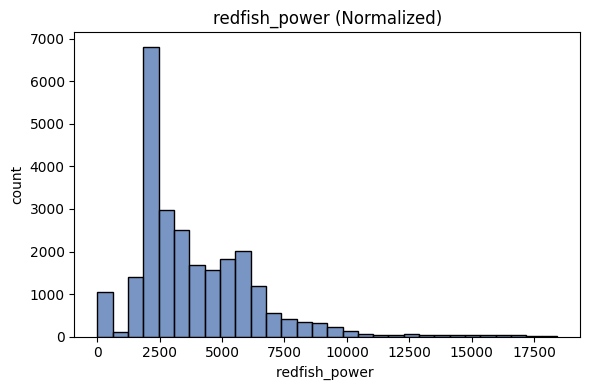

Normalized redfish_power statistics:
Mean: 3887.45
Median: 3169.37
Std Dev: 2455.87
Min: 11.10
Max: 18409.31


In [55]:
# 1% sample distribution histogram for redfish_power (normalized by 72)
# Install visualization packages (SparkCaster kernel workaround)
import subprocess
import sys
import importlib
import site

def install_and_import(package_name, import_name=None):
    """Install package and reload site-packages to make it importable"""
    if import_name is None:
        import_name = package_name
    
    try:
        return __import__(import_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', 
            '--user', '--upgrade', package_name
        ])
        # Reload site packages to pick up newly installed packages
        importlib.reload(site)
        # Force reimport of sys.path
        import site as site_module
        site_module.main()
        return __import__(import_name)

# Install required packages
install_and_import('matplotlib')
install_and_import('scipy')
install_and_import('seaborn')

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# Support either pandas or Spark DataFrame
if hasattr(df_redfish_powershelf_imputed_enriched, 'toPandas'):
    # Spark DataFrame
    sample_df = df_redfish_powershelf_imputed_enriched.sample(0.001, seed=42)
    data = sample_df.select('redfish_power').dropna().toPandas()['redfish_power'].to_numpy()
else:
    # pandas DataFrame
    sample_df = df_redfish_powershelf_imputed_enriched.sample(frac=0.001, random_state=42)
    data = sample_df['redfish_power'].dropna().to_numpy()

# Divide redfish_power by 72 to normalize
data = data / 18 *0.88

# Create the histogram
plt.figure(figsize=(6, 4))
sns.histplot(data, bins=30, color='#4C72B0')
plt.title('redfish_power (Normalized)')
plt.xlabel('redfish_power ')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# Print some statistics about the normalized data
print(f"Normalized redfish_power statistics:")
print(f"Mean: {np.mean(data):.2f}")
print(f"Median: {np.median(data):.2f}")
print(f"Std Dev: {np.std(data):.2f}")
print(f"Min: {np.min(data):.2f}")
print(f"Max: {np.max(data):.2f}")
